### Импорт

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import plotly.express as px
import logging


from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
import optuna
from optuna import Trial, create_study
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


import warnings
warnings.filterwarnings("ignore")


pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature


from dotenv import load_dotenv
import os
import boto3

import os
import zipfile
import tarfile
from pathlib import Path
from config import PATHS
import requests


In [4]:
# Загружаем переменные из .env
load_dotenv()

# Настройки из .env
endpoint_url = os.getenv("S3_ENDPOINT_URL")
aws_access_key_id = os.getenv("AWS_ACCESS_KEY_ID")
aws_secret_access_key = os.getenv("AWS_SECRET_ACCESS_KEY")
bucket_name = os.getenv("S3_BUCKET_NAME")

# Настройка окружения (для mlflow или boto3)
os.environ["S3_ENDPOINT_URL"] = endpoint_url
os.environ["AWS_ACCESS_KEY_ID"] = aws_access_key_id
os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret_access_key
os.environ["MLFLOW_S3_ENDPOINT_URL"] = endpoint_url

# Создание клиента boto3
s3 = boto3.client(
    's3',
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key,
    endpoint_url=endpoint_url
)

# Проверка доступа
response = s3.list_objects_v2(Bucket=bucket_name)
for obj in response.get("Contents", [])[:10]:
    print(obj["Key"])


0/241f332505844403a18abf5de24ad107/artifacts/models/MLmodel
0/241f332505844403a18abf5de24ad107/artifacts/models/conda.yaml
0/241f332505844403a18abf5de24ad107/artifacts/models/model.pkl
0/241f332505844403a18abf5de24ad107/artifacts/models/python_env.yaml
0/241f332505844403a18abf5de24ad107/artifacts/models/requirements.txt
0/53599d73068d478d9e795f6af56a4173/artifacts/models/MLmodel
0/53599d73068d478d9e795f6af56a4173/artifacts/models/conda.yaml
0/53599d73068d478d9e795f6af56a4173/artifacts/models/model.pkl
0/53599d73068d478d9e795f6af56a4173/artifacts/models/python_env.yaml
0/53599d73068d478d9e795f6af56a4173/artifacts/models/requirements.txt


In [3]:
def download_from_yandex_disk(public_url: str, save_path: str):
    """
    Скачивает файл с Яндекс.Диска по ссылке.
    """
    print("Начинаю загрузку с Яндекс.Диска...")
    print(f"Публичная ссылка: {public_url}")
    print(f"Файл будет сохранён в: {save_path}")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    try:
       
        api_url = "https://cloud-api.yandex.net/v1/disk/public/resources/download"
        params = {"public_key": public_url}

        print("Запрос прямой ссылки...")
        response = requests.get(api_url, params=params)
        response.raise_for_status()

        href = response.json().get("href")
        if not href:
            print("Не удалось получить прямую ссылку (href).")
            return False

        print("Прямая ссылка получена, начинаю скачивание...")

        
        file_response = requests.get(href, stream=True)
        file_response.raise_for_status()

        total_size = int(file_response.headers.get("content-length", 0))
        downloaded = 0

        with open(save_path, "wb") as f:
            for chunk in file_response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)

                    if total_size:
                        percent = (downloaded / total_size) * 100
                        print(f"\rПрогресс: {percent:.1f}%", end="")

        print(f"\nФайл загружен: {save_path}")
        return True

    except Exception as e:
        print(f"Ошибка при скачивании: {e}")
        return False


def extract_archive(archive_path: str, extract_to: str):
    """
    Разархивирует zip или tar архив.
    """
    print(f"Начинаю разархивирование {archive_path}")
    os.makedirs(extract_to, exist_ok=True)

    archive_path = Path(archive_path)

    try:
        if archive_path.suffix == '.zip':
            with zipfile.ZipFile(archive_path, 'r') as zip_ref:
                zip_ref.extractall(extract_to)

        elif archive_path.suffix in ['.tar', '.gz', '.tgz'] or '.tar.' in archive_path.name:
            if archive_path.suffix in ['.gz', '.tgz']:
                mode = 'r:gz'
            elif archive_path.suffix == '.bz2':
                mode = 'r:bz2'
            else:
                mode = 'r'

            with tarfile.open(archive_path, mode) as tar_ref:
                tar_ref.extractall(extract_to)
        else:
            print("Неизвестный формат архива.")
            return False

        print(f"Разархивировано в: {extract_to}")
        return True

    except Exception as e:
        print(f"Ошибка разархивирования: {e}")
        return False



print("Запуск get_raw_data.py")

url = "https://disk.yandex.ru/d/XPthmNk_pqEDaQ"

print("PATHS:", PATHS) 

archive_path = PATHS['raw_data']
extract_path = PATHS['extracted_data']

print(f"\nСкачивание данных с: {url}")
print(f"Сохранение архива в: {archive_path}")

ok = download_from_yandex_disk(url, archive_path)

if ok:
    print("\nНачинаю разархивирование")
    extract_archive(archive_path, extract_path)
else:
    print("Ошибка при скачивании файла")


Запуск get_raw_data.py
PATHS: {'raw_data': '/home/mle-user/mle_projects/e_commerce_recsys/data/archive.zip', 'extracted_data': '/home/mle-user/mle_projects/e_commerce_recsys/data/archive', 'category_tree_csv': '/home/mle-user/mle_projects/e_commerce_recsys/category_tree.csv', 'events_csv': '/home/mle-user/mle_projects/e_commerce_recsys/events.csv', 'item_properties_part1_csv': '/home/mle-user/mle_projects/e_commerce_recsys/item_properties_part1.csv', 'item_properties_part2_csv': '/home/mle-user/mle_projects/e_commerce_recsys/item_properties_part2.csv', 'processed_data': '/home/mle-user/mle_projects/e_commerce_recsys/data/processed'}

Скачивание данных с: https://disk.yandex.ru/d/XPthmNk_pqEDaQ
Сохранение архива в: /home/mle-user/mle_projects/e_commerce_recsys/data/archive.zip
Начинаю загрузку с Яндекс.Диска...
Публичная ссылка: https://disk.yandex.ru/d/XPthmNk_pqEDaQ
Файл будет сохранён в: /home/mle-user/mle_projects/e_commerce_recsys/data/archive.zip
Запрос прямой ссылки...
Прямая ссы

Прогресс: 100.0%
Файл загружен: /home/mle-user/mle_projects/e_commerce_recsys/data/archive.zip

Начинаю разархивирование
Начинаю разархивирование /home/mle-user/mle_projects/e_commerce_recsys/data/archive.zip
Разархивировано в: /home/mle-user/mle_projects/e_commerce_recsys/data/archive


### Просмотр и EDA

In [4]:
df_category_tree = pd.read_csv(r'/home/mle-user/mle_projects/e_commerce_recsys/data/archive/category_tree.csv')
df_category_tree.head(5)

,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0


In [5]:
df_category_tree.rename(columns = {'categoryid' : 'category_id', 'parentid' : 'parent_id'}, inplace = True)
print('Инфо о данных с категориями:')
print(df_category_tree.info())
print('\n\n')
print('Пропуски в данных с категориями:')
print(df_category_tree.isna().sum())
print('Дубликаты в данных с категориями:')
print(df_category_tree.duplicated().sum())

Инфо о данных с категориями:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   category_id  1669 non-null   int64  
 1   parent_id    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB
None



Пропуски в данных с категориями:
category_id     0
parent_id      25
dtype: int64
Дубликаты в данных с категориями:
0


In [6]:
df_events = pd.read_csv(r'/home/mle-user/mle_projects/e_commerce_recsys/data/archive/events.csv')
df_events.head(5)

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [7]:
df_events.rename(columns = {'visitorid' : 'visitor_id', 'itemid' : 'item_id', 'transactionid' : 'transaction_id'}, inplace = True)
print('Инфо о данных с событиями:')
print(df_events.info())
print('\n\n')
print('Пропуски в данных с событиями:')
print(df_events.isna().sum())
print('Дубликаты в данных с событиями:')
print(df_events.duplicated().sum())

Инфо о данных с событиями:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   timestamp       int64  
 1   visitor_id      int64  
 2   event           object 
 3   item_id         int64  
 4   transaction_id  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB
None



Пропуски в данных с событиями:
timestamp               0
visitor_id              0
event                   0
item_id                 0
transaction_id    2733644
dtype: int64
Дубликаты в данных с событиями:


460


In [8]:
df_item_properties_part1 = pd.read_csv(r'/home/mle-user/mle_projects/e_commerce_recsys/data/archive/item_properties_part1.csv')
df_item_properties_part1.head(5) 

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [9]:
df_item_properties_part2 = pd.read_csv(r'/home/mle-user/mle_projects/e_commerce_recsys/data/archive/item_properties_part2.csv')
df_item_properties_part2.head(5)

,timestamp,itemid,property,value
0,1433041200000,183478,561,769062
1,1439694000000,132256,976,n26.400 1135780
2,1435460400000,420307,921,1149317 1257525
3,1431831600000,403324,917,1204143
4,1435460400000,230701,521,769062


Таблицы с описаниями товаров можно склеить в одну, там одно и то же.

In [10]:
df_item_properties = pd.concat([df_item_properties_part1, df_item_properties_part2], axis = 0)

In [11]:
df_item_properties.rename(columns = {'itemid' : 'item_id'}, inplace = True)
print('Инфо о данных с описаниями айтемов:')
print(df_item_properties.info())
print('\n\n')
print('Пропуски в данных с описаниями айтемов:')
print(df_item_properties.isna().sum())
print('Дубликаты в данных с описаниями айтемов:')
print(df_item_properties.duplicated().sum())

Инфо о данных с описаниями айтемов:
<class 'pandas.core.frame.DataFrame'>
Index: 20275902 entries, 0 to 9275902
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   item_id    int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 773.5+ MB
None



Пропуски в данных с описаниями айтемов:
timestamp    0
item_id      0
property     0
value        0
dtype: int64
Дубликаты в данных с описаниями айтемов:
0


Выводы по просмотру данных:

1) category_tree.csv — таблица из двух столбцов: «родительская категория» и «дочерняя категория». Типичный способ представления таблицы в виде дерева.

- category_id
- parent_id

2) events.csv — таблица с логом событий:

- timestamp — временная метка события,
- visitor_id — идентификатор пользователя,
- event — событие (просмотр, добавление в корзину, покупка),
- item_id — идентификатор товара,
- transaction_id — идентификатор транзакции (покупки).

3) item_properties.csv — таблица со свойствами товаров:

- timestamp — временная метка добавления свойства,
- item_id — идентификатор товара,
- property — свойство товара,
- value — значение свойства.


Посмотрим внимательнее на пропуки, дубли и закономерности.

In [12]:
del df_item_properties_part1
del df_item_properties_part2

Визуально property похоже на category_id. Посмотрим, насколько ни похожи/связаны.

In [13]:
category_ids = set(df_category_tree['category_id'].astype(str))
properties = set(df_item_properties['property'].astype(str))

# Property, которых НЕТ в category_id
non_category_properties = properties - category_ids

print(f"Всего уникальных property: {len(properties)}")
print(f"Property, которые есть в category_id: {len(category_ids.intersection(properties))}")
print(f"Property, которых НЕТ в category_id: {len(non_category_properties)}")
print(f"\nПримеры property БЕЗ category_id: {list(non_category_properties)[:20]}")

Всего уникальных property: 1104
Property, которые есть в category_id: 1082
Property, которых НЕТ в category_id: 22

Примеры property БЕЗ category_id: ['1062', '307', '347', '974', '171', '80', '721', '930', '899', '462', '280', 'categoryid', '181', '554', '306', 'available', '345', '919', '1046', '300']


Теперь надо подумать, что делать с value и какой смысл этой колонки.

In [14]:
unique_values = df_item_properties['value'].unique()
unique_values[:20]

array(['1338', '1116713 960601 n277.200',
       'n552.000 639502 n720.000 424566', 'n15360.000', '828513', '0',
       '1121373', '319724', '1330310', '1141052 n48.000',
       '1038400 45956 n504.000', '1283144 353870', '1026952 1162729',
       'n21000.000', 'n5400.000', '1292080',
       'n36.000 1186610 119932 717520 903287 98606 632686 1117759 504389 227411 768453 414047 1008741 561431 508431 621351 976840 260167 934278 388767 42948',
       '857891 593337', 'n480.000 639502 189174', '519769'], dtype=object)

In [15]:
# Посмотрим примеры для какого-то конкретного property
prop_name = '561'  
sample = df_item_properties[df_item_properties['property'] == prop_name]['value'].head(20)
print(sample)


print(f"С пробелами: {df_item_properties['value'].str.contains(' ').sum()}")
print(f"С 'n': {df_item_properties['value'].str.contains('n').sum()}")
pattern = r'^\d+$'
print(f"Только цифры: {df_item_properties['value'].str.match(pattern).sum()}")

870                            769062
1301                   1294803 101489
2801                           769062
3873                           769062
4398                           769062
4772                   1294803 101489
5803                           769062
7494                           769062
7812                   1294803 101489
8208                   1294803 101489
8944                   991263 1238769
9905     769062 1294803 101489 769062
10327                  1294803 101489
12632                  1294803 101489
13617                  1294803 101489
13831                          769062
14472    769062 1294803 101489 769062
14824                  1294803 101489
16690                  1294803 101489
16904      769062 115724 86958 769062
Name: value, dtype: object
С пробелами: 7331908
С 'n': 5175270
Только цифры: 10631047


In [16]:
all_values = set(' '.join(df_item_properties['value'].astype(str)).split())

visitor_ids = set(df_events['visitor_id'].astype(str))

print(f"Совпадений с visitor_id: {len(all_values.intersection(visitor_ids))}")

Совпадений с visitor_id: 1233356


Значение с n то ли количество, то ли количество. Посмотрим, на что похоже.

In [17]:
# Правильный паттерн - только с точкой и разумной длиной
n_pattern = df_item_properties['value'].str.match(r'^n\d{1,10}\.\d{1,3}$', na=False)
n_df = df_item_properties[n_pattern]['value'].str.replace('n', '', regex=False).astype(float)

print(f"Значений формата 'nXXX.XXX': {n_pattern.sum()}")
print(f"Мин: {n_df.min():.2f}")
print(f"Макс: {n_df.max():.2f}")
print(f"Среднее: {n_df.mean():.2f}")


Значений формата 'nXXX.XXX': 2289524
Мин: 0.00
Макс: 9803408448.00
Среднее: 21009055.87


In [18]:
df_item_properties[df_item_properties['value'].str.contains('n9803408448.000', na=False)]

,timestamp,item_id,property,value
8305565,1431226800000,179359,917,n9803408448.000


Это точно не цены, и не количество.

In [19]:
# Какие property содержат значения с 'n'?
n_properties = df_item_properties[df_item_properties['value'].str.contains('^n', na=False, regex=True)]['property'].unique()
print(f"Property со значениями 'nXXX': {len(n_properties)}")
print(f"Примеры: {n_properties[:20]}")

# Проверить для конкретного property
sample_prop = n_properties[0]
sample_data = df_item_properties[df_item_properties['property'] == sample_prop][['item_id', 'property', 'value']].head(20)
print(f"\nПример для property={sample_prop}:")
print(sample_data)

Property со значениями 'nXXX': 537
Примеры: ['400' '790' '0' '566' '134' '19' '881' '188' '888' '663' '619' '917'
 '202' '719' '964' '810' '175' '631' '1075' '720']

Пример для property=400:
      item_id property                                     value
2      395014      400           n552.000 639502 n720.000 424566
11     244127      400           n552.000 639502 n720.000 424566
89     368230      400  1297729 n720.000 1178208 n900.000 424566
95     428812      400           n552.000 639502 n720.000 424566
138    370490      400                           n410.400 424566
311     92817      400  1297729 n720.000 1178208 n900.000 424566
448     86663      400           n552.000 639502 n720.000 424566
476    376639      400           n552.000 639502 n720.000 424566
709    424158      400  1297729 n660.000 1178208 n720.000 424566
754     37530      400           n552.000 639502 n720.000 424566
764      1447      400  1297729 n720.000 1178208 n900.000 424566
856    260777      400       

In [20]:
# Для property=400 разделим на item_id и числа
prop_400 = df_item_properties[df_item_properties['property'] == '400'].copy()

# Извлечем все числа с 'n'
n_numbers = []
for val in prop_400['value']:
    n_numbers.extend([x for x in str(val).split() if x.startswith('n')])

n_numbers_clean = [float(x.replace('n', '')) for x in n_numbers[:1000]]

print(f"Мин: {min(n_numbers_clean):.2f}")
print(f"Макс: {max(n_numbers_clean):.2f}")
print(f"Уникальных значений: {len(set(n_numbers_clean))}")
print(f"Топ-10 частых: {sorted(set(n_numbers_clean))[:10]}")

Мин: 72.00
Макс: 3540.00
Уникальных значений: 105
Топ-10 частых: [72.0, 78.0, 84.0, 90.0, 96.0, 102.0, 204.0, 216.0, 222.84, 260.4]


Я не понимаю, что такое значение с n. Не буду брать в анализ.

In [21]:
df_item_properties['interaction_visitor'] = df_item_properties['value'].astype(str).apply(
    lambda x: [v for v in x.split() if v in visitor_ids]
)

In [22]:
df_item_properties.head(20)

,timestamp,item_id,property,value,interaction_visitor
0,1435460400000,460429,categoryid,1338,[1338]
1,1441508400000,206783,888,1116713 960601 n277.200,"[1116713, 960601]"
2,1439089200000,395014,400,n552.000 639502 n720.000 424566,"[639502, 424566]"
3,1431226800000,59481,790,n15360.000,[]
4,1431831600000,156781,917,828513,[828513]
5,1436065200000,285026,available,0,[0]
6,1434250800000,89534,213,1121373,[1121373]
7,1431831600000,264312,6,319724,[319724]
8,1433646000000,229370,202,1330310,[1330310]
9,1434250800000,98113,451,1141052 n48.000,[1141052]


В принципе, это дубль смысла таблицы events.

Теперь посмотрим, сколько Item_id из df_item_properties участвует в событиях и наоборот, сколько айтемов из событий описано в свойствах товаров.

In [23]:
unique_item_ids = set(df_item_properties['item_id'].astype(str))
items_in_events = set(df_events['item_id'].astype(str))

# Items из properties, которых НЕТ в events
properties_not_in_events = unique_item_ids - items_in_events

# Items из events, которых НЕТ в properties
events_not_in_properties = items_in_events - unique_item_ids

print(f"Всего item_id в properties: {len(unique_item_ids)}")
print(f"Всего item_id в events: {len(items_in_events)}")
print(f"\nПересечение (есть в обеих таблицах): {len(unique_item_ids.intersection(items_in_events))}")
print(f"\nТолько в properties (НЕТ в events): {len(properties_not_in_events)} ({len(properties_not_in_events)/len(unique_item_ids)*100:.1f}%)")
print(f"Только в events (НЕТ в properties): {len(events_not_in_properties)} ({len(events_not_in_properties)/len(items_in_events)*100:.1f}%)")

Всего item_id в properties: 417053
Всего item_id в events: 235061

Пересечение (есть в обеих таблицах): 185246

Только в properties (НЕТ в events): 231807 (55.6%)
Только в events (НЕТ в properties): 49815 (21.2%)


Много айтемов из событий не покрыты описаниями, а много айтемов из описаний не участвовали в событиях. Посмотрим, может наша новая колонка interaction_visitor нам даст какую-то информацию.

In [24]:
interaction_empty = df_item_properties[df_item_properties['interaction_visitor'].apply(lambda x: x == [] or x == [0])]
interaction_empty

,timestamp,item_id,property,value,interaction_visitor
3,1431226800000,59481,790,n15360.000,[]
14,1434250800000,169055,790,n21000.000,[]
16,1435460400000,178601,790,n5400.000,[]
24,1433646000000,419661,134,n12.000,[]
30,1439694000000,218734,881,n60.000,[]
...,...,...,...,...,...
9275868,1433041200000,463381,790,n0.000,[]
9275877,1436670000000,147935,790,n42720.000,[]
9275891,1432436400000,206640,790,n9600.000,[]
9275894,1431226800000,58255,917,n1020780.000,[]


In [25]:
# Извлечем всех visitor_id из interaction_visitor
interaction_visitors = set()
for visitors_list in df_item_properties['interaction_visitor']:
    if visitors_list:
        interaction_visitors.update(visitors_list)

# Visitor_id из events
events_visitors = set(df_events['visitor_id'].astype(str))

# Сопоставить
overlap = interaction_visitors.intersection(events_visitors)

print(f"Уникальных visitor_id в interaction_visitor: {len(interaction_visitors)}")
print(f"Уникальных visitor_id в events: {len(events_visitors)}")
print(f"Пересечение: {len(overlap)} ({len(overlap)/len(interaction_visitors)*100:.1f}%)")
print(f"\nVisitor только в interaction_visitor: {len(interaction_visitors - events_visitors)}")
print(f"Visitor только в events: {len(events_visitors - interaction_visitors)}")

Уникальных visitor_id в interaction_visitor: 1233356
Уникальных visitor_id в events: 1407580
Пересечение: 1233356 (100.0%)

Visitor только в interaction_visitor: 0
Visitor только в events: 174224


- 100% visitor_id из interaction_visitor есть в events
- interaction_visitor - это подмножество events
- 174,224 пользователей есть только в events (не попали в interaction_visitor)

Что это значит:
- interaction_visitor содержит ту же информацию, что и events, но в другом формате:

- events -> лог действий (построчно: кто, что, когда)

- interaction_visitor -> предрасчитанные связи товар→пользователи (агрегированные)

Но посмотрим, ассоциированы ли эти посетители с теми же товарами, что и в events?

In [26]:
# Возьмем один товар с interaction_visitor
sample = df_item_properties[df_item_properties['interaction_visitor'].apply(len) > 0].iloc[0]
item_id = sample['item_id']
visitors_from_props = set(sample['interaction_visitor'])

# Найдем visitor_id для этого товара в events
visitors_from_events = set(df_events[df_events['item_id'] == item_id]['visitor_id'].astype(str))

print(f"Товар: {item_id}")
print(f"Visitor_id в interaction_visitor: {len(visitors_from_props)}")
print(f"Visitor_id в events: {len(visitors_from_events)}")
print(f"Пересечение: {len(visitors_from_props.intersection(visitors_from_events))}")
print(f"\nСовпадают ли списки? {visitors_from_props == visitors_from_events}")

Товар: 460429
Visitor_id в interaction_visitor: 1
Visitor_id в events: 1
Пересечение: 0

Совпадают ли списки? False


Значит, interaction_visitor содержит реальных пользователей из events, но для других товаров. Это какие-то другие связи. Но какие?

In [27]:
# Найдем строки с visitor_id + n
mixed_pattern = df_item_properties[
    (df_item_properties['interaction_visitor'].apply(len) > 0) & 
    (df_item_properties['value'].str.contains('n\d+\.', na=False, regex=True))
]

print(f"Строк с visitor_id + n: {len(mixed_pattern)}")
print("\nПримеры:")
for i in range(5):
    row = mixed_pattern.iloc[i]
    print(f"Value: {row['value']}")
    print(f"Visitors: {row['interaction_visitor'][:3]}")
    print()

Строк с visitor_id + n: 2854831

Примеры:
Value: 1116713 960601 n277.200
Visitors: ['1116713', '960601']

Value: n552.000 639502 n720.000 424566
Visitors: ['639502', '424566']

Value: 1141052 n48.000
Visitors: ['1141052']

Value: 1038400 45956 n504.000
Visitors: ['1038400', '45956']

Value: n552.000 639502 n720.000 424566
Visitors: ['639502', '424566']



Это уже какие-то веса или скоры по товарам для разных пользователям. Не будем это трогать. Берем только property - категорию.

Посмотрим, как представлены дочерние и родительские категории.

In [28]:
print(df_category_tree['parent_id'].nunique())
print(df_category_tree['category_id'].nunique())

362
1669


Среднее количество category_id на parent_id: 11.18


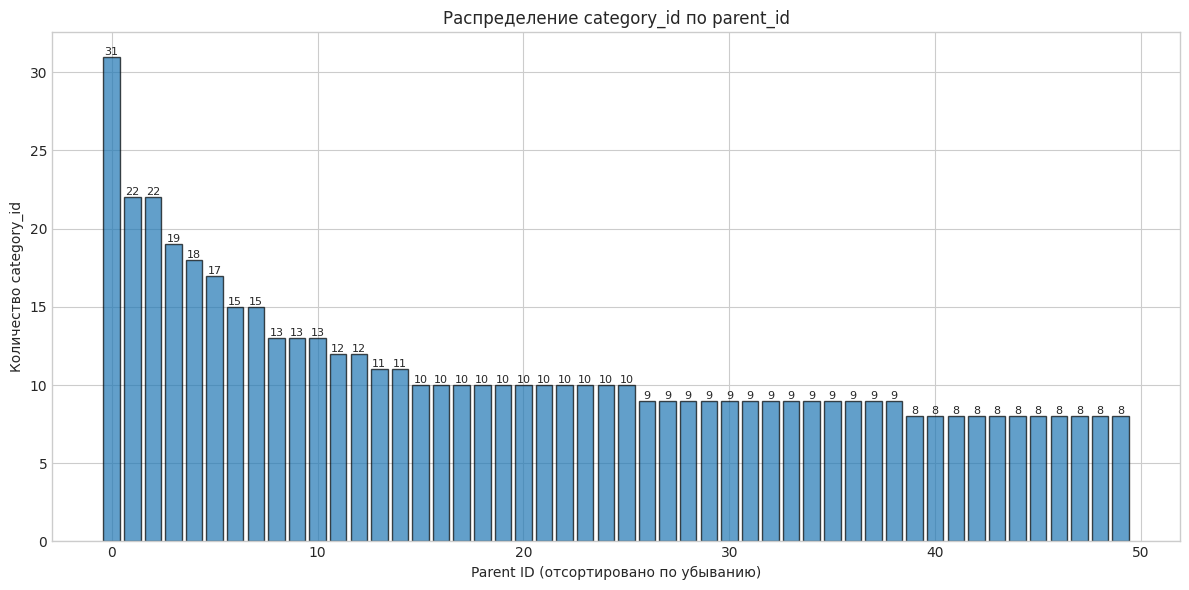

In [29]:
category_groups = df_category_tree.groupby('parent_id')['category_id'].count().reset_index()
category_groups = category_groups.sort_values('category_id', ascending=False).reset_index(drop=True)[:50]

print(f"Среднее количество category_id на parent_id: {category_groups['category_id'].mean():.2f}")

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(category_groups)), category_groups['category_id'], edgecolor='black', alpha=0.7)

for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.xlabel('Parent ID (отсортировано по убыванию)')
plt.ylabel('Количество category_id')
plt.title('Распределение category_id по parent_id')
plt.tight_layout()
plt.show()

У 25 category_id пропущен parent_id, посмотрим на это.

In [30]:
df_category_tree[df_category_tree['parent_id'].isna()].head(5)

,category_id,parent_id
5,231,NaN
589,791,NaN
861,1490,NaN
939,431,NaN
1111,755,NaN


Заменим на что-то более понятное.

In [31]:
df_category_tree['parent_id'] = df_category_tree['parent_id'].fillna('no_parent_cat_name')
df_category_tree[df_category_tree['parent_id'] == 'no_parent_cat_name'].head(5)

,category_id,parent_id
5,231,no_parent_cat_name
589,791,no_parent_cat_name
861,1490,no_parent_cat_name
939,431,no_parent_cat_name
1111,755,no_parent_cat_name


Теперь внимательнее посмотрим на пропуски в events. Согласно первичному анализу, там было: 2_733_644 пропуска из 2_756_101 строк.

In [32]:
df_events[df_events['transaction_id'].isna()].head(5)

,timestamp,visitor_id,event,item_id,transaction_id
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [33]:
df_events[~df_events['transaction_id'].isna()].head(5)

,timestamp,visitor_id,event,item_id,transaction_id
130,1433222276276,599528,transaction,356475,4000.0
304,1433193500981,121688,transaction,15335,11117.0
418,1433193915008,552148,transaction,81345,5444.0
814,1433176736375,102019,transaction,150318,13556.0
843,1433174518180,189384,transaction,310791,7244.0


In [34]:
actions = df_events.groupby('event')['transaction_id'].count().reset_index()

actions

,event,transaction_id
0,addtocart,0
1,transaction,22457
2,view,0


In [35]:
print(len(df_events[df_events['transaction_id'].isna()]))
print(len(df_events[df_events['transaction_id'].notna()]))
print(f"Процент покупок среди всех событий: {round(len(df_events[df_events['transaction_id'].notna()]) / len(df_events) * 100, 3)}%")

2733644
22457
Процент покупок среди всех событий: 0.815%


Покупок из всех событий меньше 1 процента. 

Тепеь посмотрим на дубликаты events.

In [36]:
dups = df_events[df_events.duplicated(keep=False)].sort_values(list(df_events.columns))
dups

,timestamp,visitor_id,event,item_id,transaction_id
1466550,1430639017006,771203,view,250578,NaN
1471736,1430639017006,771203,view,250578,NaN
1482986,1430780975099,234788,addtocart,33,NaN
1496938,1430780975099,234788,addtocart,33,NaN
1489030,1430788228572,594432,addtocart,311596,NaN
...,...,...,...,...,...
1448726,1442435309784,739520,addtocart,308273,NaN
1460622,1442502594303,159701,addtocart,139030,NaN
1462130,1442502594303,159701,addtocart,139030,NaN
1457308,1442525777257,143657,addtocart,37115,NaN


Можно удалить.

In [37]:
print(len(df_events))
df_events = df_events.drop_duplicates()
print(len(df_events))

2756101


2755641


Все правильно, на 460 меньше.

Теперь можно сджойнить айтемы с деревом категорий.

In [38]:
print(df_item_properties['property'].dtype)
print(df_category_tree['category_id'].dtype)


object
int64


In [39]:
df_item_properties['property'] = df_item_properties['property'].astype(str).str.strip()
df_category_tree['category_id'] = df_category_tree['category_id'].astype(str).str.strip()

In [40]:
print(df_item_properties['property'].dtype)
print(df_category_tree['category_id'].dtype)

object
object


In [41]:
df_item_properties = df_item_properties.merge(
    df_category_tree,
    left_on='property',
    right_on='category_id',
    how='left'
)


In [42]:
print(df_item_properties['category_id'].notna().sum())
print(df_item_properties['category_id'].isna().sum())

17873746
2402156


In [43]:
df_item_properties

,timestamp,item_id,property,value,interaction_visitor,category_id,parent_id
0,1435460400000,460429,categoryid,1338,[1338],NaN,NaN
1,1441508400000,206783,888,1116713 960601 n277.200,"[1116713, 960601]",888,866.0
2,1439089200000,395014,400,n552.000 639502 n720.000 424566,"[639502, 424566]",400,110.0
3,1431226800000,59481,790,n15360.000,[],790,1492.0
4,1431831600000,156781,917,828513,[828513],917,1374.0
...,...,...,...,...,...,...,...
20275897,1433646000000,236931,929,n12.000,[],929,1027.0
20275898,1440903600000,455746,6,150169 639134,"[150169, 639134]",6,933.0
20275899,1439694000000,347565,686,610834,[610834],686,594.0
20275900,1433646000000,287231,867,769062,[769062],867,441.0


In [44]:
df_events

,timestamp,visitor_id,event,item_id,transaction_id
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
...,...,...,...,...,...
2756096,1438398785939,591435,view,261427,NaN
2756097,1438399813142,762376,view,115946,NaN
2756098,1438397820527,1251746,view,78144,NaN
2756099,1438398530703,1184451,view,283392,NaN


Осталось разобраться с timestamp. Сейчас непонятно, какие это даты.

In [45]:
df_item_properties['timestamp'] = pd.to_datetime(df_item_properties['timestamp'], unit='ms')
df_events['timestamp'] = pd.to_datetime(df_events['timestamp'], unit='ms')


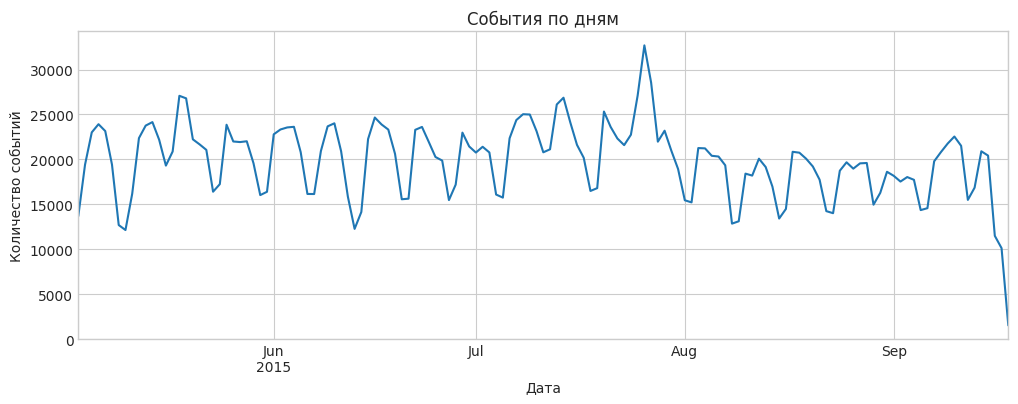

In [46]:
df_events.resample("D", on="timestamp").size().plot(figsize=(12,4))
plt.title("События по дням")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.show()

In [47]:
print(df_events['timestamp'].max())
print(df_events['timestamp'].min())

2015-09-18 02:59:47.788000
2015-05-03 03:00:04.384000


In [48]:
processed_path = PATHS['processed_data']
os.makedirs(processed_path, exist_ok=True)
df_item_properties.to_csv(f"{processed_path}/item_properties.csv", index=False)
df_category_tree.to_csv(f"{processed_path}/category_tree.csv", index=False)
df_events.to_csv(f"{processed_path}/events.csv", index=False)
print(f"Сохранение обработанных данных в: {processed_path} завершено")

Сохранение обработанных данных в: /home/mle-user/mle_projects/e_commerce_recsys/data/processed завершено


### Выводы по EDA

- Были убраны дубликаты из событий (460)
- Пропуски в столбце с транзакциями - это просмотры или добавления в корзину
- Столбец property  - это категория, поэтому таблица с деревом категорий была приклеена к свойствам товаров. Позже это инфо будет использовано в ранжировании рекомендаций алгоритма ALS.
- Свойства товаров были изначально двумя таблицами, теперь они склеены в одну.
- Данные в событиях у нас разреженные: покупок среди всех действий 0.815%
- Данные растянуты во времени с мая по сентябрь 2015 года.

Версионируем обработанные данные, сохраним в нужном бакете.

dvc init

git add .dvc .gitignore

git commit -m "init DVC"

dvc remote add -d myremote s3://s3-student-mle-20250729-0060996a6e-freetrack/dvcstore

dvc remote modify myremote --unset profile

dvc remote modify myremote access_key_id $AWS_ACCESS_KEY_ID

dvc remote modify myremote secret_access_key $AWS_SECRET_ACCESS_KEY

dvc remote modify myremote endpointurl https://storage.yandexcloud.net

dvc add data/processed/item_properties.csv

dvc add data/processed/category_tree.csv

dvc add data/processed/events.csv

git add data/processed/*.csv.dvc .gitignore

git commit -m "Add processed data to DVC"



Теперь можно сделать Restart Kernel.

### Построение модели рекомендаций

In [102]:
# импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import plotly.express as px
import logging
import random

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
import optuna
from optuna import Trial, create_study
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


import warnings
warnings.filterwarnings("ignore")


pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
import mlflow.pyfunc

from dotenv import load_dotenv
import os
import boto3

import optuna
from catboost import CatBoostRanker

import zipfile
import tarfile
from pathlib import Path
from config import PATHS
import requests
from collections import defaultdict
from scipy.sparse import csr_matrix
from implicit.als import AlternatingLeastSquares
from sklearn.preprocessing import LabelEncoder
import pickle
from tqdm import tqdm
from catboost import CatBoostRanker, Pool

import  s3fs

In [5]:
# Загружаем переменные из .env
load_dotenv()

# Настройки из .env
endpoint_url = os.getenv("S3_ENDPOINT_URL")
aws_access_key_id = os.getenv("AWS_ACCESS_KEY_ID")
aws_secret_access_key = os.getenv("AWS_SECRET_ACCESS_KEY")
bucket_name = os.getenv("S3_BUCKET_NAME")

# Настройка окружения (для mlflow или boto3)
os.environ["S3_ENDPOINT_URL"] = endpoint_url
os.environ["AWS_ACCESS_KEY_ID"] = aws_access_key_id
os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret_access_key
os.environ["MLFLOW_S3_ENDPOINT_URL"] = endpoint_url

# Создание клиента boto3
s3 = boto3.client(
    's3',
    aws_access_key_id=aws_access_key_id,
    aws_secret_access_key=aws_secret_access_key,
    endpoint_url=endpoint_url
)

# Проверка доступа
response = s3.list_objects_v2(Bucket=bucket_name)
for obj in response.get("Contents", [])[:10]:
    print(obj["Key"])

0/241f332505844403a18abf5de24ad107/artifacts/models/MLmodel
0/241f332505844403a18abf5de24ad107/artifacts/models/conda.yaml
0/241f332505844403a18abf5de24ad107/artifacts/models/model.pkl
0/241f332505844403a18abf5de24ad107/artifacts/models/python_env.yaml
0/241f332505844403a18abf5de24ad107/artifacts/models/requirements.txt
0/53599d73068d478d9e795f6af56a4173/artifacts/models/MLmodel
0/53599d73068d478d9e795f6af56a4173/artifacts/models/conda.yaml
0/53599d73068d478d9e795f6af56a4173/artifacts/models/model.pkl
0/53599d73068d478d9e795f6af56a4173/artifacts/models/python_env.yaml
0/53599d73068d478d9e795f6af56a4173/artifacts/models/requirements.txt


In [51]:
# загружаем данные
df_events = pd.read_csv(r'/home/mle-user/mle_projects/e_commerce_recsys/data/processed/events.csv')
df_items = pd.read_csv(r'/home/mle-user/mle_projects/e_commerce_recsys/data/processed/item_properties.csv')

План действий:

- По df_events построим ALS
- затем ранжируем через catboost
- оптимизивраоть будем precision@10, recall@10
- также найдем топ-100 самых популярных продуктов черех events для холодного старта
- также найдем популярных товары из родительских категорий для рекомендаций по просмотрам
- события буду поделены глобально на 2 части: одна для обучения первой модели, вторая для дообучения (70 и 30% данных)

In [52]:
# РАЗДЕЛЕНИЕ ДАННЫХ ПО ДАТАМ
df_events['datetime'] = pd.to_datetime(df_events['timestamp'])

train_end = '2015-08-01'  # 80% для обучения
retrain_end = '2015-09-01'  # 10% для валидации
# Остаток (10%) для имитации дообучения

train_fit = df_events[df_events['datetime'] < train_end]
train_val = df_events[(df_events['datetime'] >= train_end) & (df_events['datetime'] < retrain_end)]
new_events = df_events[df_events['datetime'] >= retrain_end]

print(f"Train fit: {len(train_fit):,} (до {train_end})")
print(f"Train val: {len(train_val):,} ({train_end} - {retrain_end})")
print(f"New events: {len(new_events):,} (с {retrain_end})")

Train fit: 1,898,746 (до 2015-08-01)
Train val: 553,237 (2015-08-01 - 2015-09-01)
New events: 303,658 (с 2015-09-01)


In [53]:
# ЭНКОДИНГ НА ОСНОВЕ ВСЕХ ДАННЫХ


user_encoder = LabelEncoder()
user_encoder.fit(df_events['visitor_id'])

item_encoder = LabelEncoder()
item_encoder.fit(df_events['item_id'])

# Применяем ко всем датасетам
train_fit['user_id_enc'] = user_encoder.transform(train_fit['visitor_id'])
train_fit['item_id_enc'] = item_encoder.transform(train_fit['item_id'])

train_val['user_id_enc'] = user_encoder.transform(train_val['visitor_id'])
train_val['item_id_enc'] = item_encoder.transform(train_val['item_id'])

new_events['user_id_enc'] = user_encoder.transform(new_events['visitor_id'])
new_events['item_id_enc'] = item_encoder.transform(new_events['item_id'])

print(f"\nУникальных пользователей: {len(user_encoder.classes_):,}")
print(f"Уникальных товаров: {len(item_encoder.classes_):,}")

# Сохранить энкодеры
os.makedirs('models', exist_ok=True)
with open('models/user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)
with open('models/item_encoder.pkl', 'wb') as f:
    pickle.dump(item_encoder, f)


Уникальных пользователей: 1,407,580
Уникальных товаров: 235,061


In [54]:
# ТОП-100 ПОПУЛЯРНЫХ ТОВАРОВ
top_popular = train_fit.groupby('item_id_enc').size().reset_index(name='popularity')
top_popular = top_popular.sort_values('popularity', ascending=False).head(100)
top_popular['rank'] = range(1, len(top_popular) + 1)

# Добавить оригинальные ID
top_popular['item_id'] = item_encoder.inverse_transform(top_popular['item_id_enc'])

top_popular.to_csv('models/top_popular.csv', index=False)
print(f"Топ популярных: {len(top_popular)} товаров")
print(top_popular.head())

Топ популярных: 100 товаров
        item_id_enc  popularity  rank  item_id
2304           2719        1885     1     5411
132585       156023        1581     2   309778
197512       232496        1494     3   461686
158755       186716        1464     4   370653
127571       150148        1336     5   298009


In [55]:
storage_options = {
    'key': aws_access_key_id,
    'secret': aws_secret_access_key,
    'client_kwargs': {'endpoint_url': endpoint_url}
}


# СОХРАНЯЕМ
top_popular.to_parquet(
    f's3://{bucket_name}/recsys/recommendations/top_popular.parquet',
    index=False,
    storage_options=storage_options
)

In [56]:
# СОЗДАНИЕ МАТРИЦЫ С ВЕСАМИ
train_fit['weight'] = train_fit['event'].map({'view': 1, 'addtocart': 5, 'transaction': 10})

user_item_matrix_fit = csr_matrix(
    (train_fit['weight'], (train_fit['user_id_enc'], train_fit['item_id_enc'])),
    shape=(len(user_encoder.classes_), len(item_encoder.classes_))
)

print(f"\nМатрица: {user_item_matrix_fit.shape}")
print(f"Заполненность: {user_item_matrix_fit.nnz / (user_item_matrix_fit.shape[0] * user_item_matrix_fit.shape[1]) * 100:.4f}%")


Матрица: (1407580, 235061)
Заполненность: 0.0004%


In [57]:
RANDOM_SEED = 42

In [58]:
ALS_FACTORS = 64           # Размерность латентных векторов (больше = точнее, но медленнее)
ALS_ITERATIONS = 15        # Количество итераций обучения
ALS_REGULARIZATION = 0.01  # L2 регуляризация для предотвращения переобучения
ALS_RANDOM_SEED = 42       # Для воспроизводимости результатов

In [59]:
# ALS ожидает матрицу (user x item), внутри сама транспонирует
model = AlternatingLeastSquares(
        factors=ALS_FACTORS,
        iterations=ALS_ITERATIONS,
        regularization=ALS_REGULARIZATION,
        random_state=ALS_RANDOM_SEED,
        use_gpu=False
    )

print("\nОбучение ALS...")
model.fit(user_item_matrix_fit.astype('float32'))  
print("ALS обучена")

print(f"user_factors shape: {model.user_factors.shape}")
print(f"item_factors shape: {model.item_factors.shape}")


Обучение ALS...


  0%|          | 0/15 [00:00<?, ?it/s]

ALS обучена
user_factors shape: (1407580, 64)
item_factors shape: (235061, 64)


In [60]:
# Пользователи с историей в train И присутствующие в val
users_with_history = set(train_fit['user_id_enc'].unique())
val_users = set(train_val['user_id_enc'].unique())
target_users = users_with_history & val_users

# Фильтруем по размеру модели
max_user_id = model.user_factors.shape[0]
target_users = [u for u in target_users if u < max_user_id]

print(f"Пользователей для рекомендаций: {len(target_users):,}")

# Генерация рекомендаций
personal_recs = []
for user_id in tqdm(target_users, desc="Recommendations"):
    try:
        item_ids, scores = model.recommend(
            user_id, 
            user_item_matrix_fit[user_id], 
            N=100, 
            filter_already_liked_items=True
        )
        
        for rank, (item_id, score) in enumerate(zip(item_ids, scores), 1):
            if item_id < len(item_encoder.classes_):
                personal_recs.append({
                    'user_id_enc': user_id, 
                    'item_id_enc': item_id, 
                    'score': float(score), 
                    'rank': rank
                })
    except Exception as e:
        continue

personal_als = pd.DataFrame(personal_recs)

# Добавить оригинальные ID
personal_als['visitor_id'] = user_encoder.inverse_transform(personal_als['user_id_enc'])
personal_als['item_id'] = item_encoder.inverse_transform(personal_als['item_id_enc'])

print(f"Рекомендации: {len(personal_als):,}")
print(f"Пользователей: {personal_als['user_id_enc'].nunique():,}")

Пользователей для рекомендаций: 22,800


Recommendations:   1%|          | 162/22800 [00:00<01:23, 269.64it/s]

Recommendations: 100%|██████████| 22800/22800 [01:10<00:00, 324.99it/s]


Рекомендации: 2,280,000
Пользователей: 22,800


In [61]:

# СОХРАНЯЕМ
personal_als.to_parquet(
    f's3://{bucket_name}/recsys/recommendations/personal_als.parquet',
    index=False,
    storage_options=storage_options
)

In [62]:
# ПОХОЖИЕ ТОВАРЫ
top_items = train_fit['item_id_enc'].value_counts().head(1000).index
similar_recs = []

for item_id in tqdm(top_items, desc="Similar items"):
    try:
        similar_ids, similar_scores = model.similar_items(item_id, N=11)
        for rank, (sim_item_id, score) in enumerate(zip(similar_ids[1:], similar_scores[1:]), 1):
            similar_recs.append({
                'item_id_enc': item_id, 
                'similar_item_id_enc': sim_item_id, 
                'score': score, 
                'rank': rank
            })
    except:
        continue

similar_items = pd.DataFrame(similar_recs)
similar_items.to_csv('models/similar_items.csv', index=False)
print(f"Похожие товары: {len(similar_items):,} пар")

Similar items:   7%|▋         | 68/1000 [00:00<00:02, 343.48it/s]

Similar items: 100%|██████████| 1000/1000 [00:02<00:00, 372.25it/s]


Похожие товары: 10,000 пар


In [63]:
# СОХРАНЯЕМ
similar_items.to_parquet(
    f's3://{bucket_name}/recsys/recommendations/similar_items.parquet',
    index=False,
    storage_options=storage_options
)

In [64]:
def recommend_for_user(visitor_id, N=20):
    try:
        user_id_enc = user_encoder.transform([visitor_id])[0]
        
        # Проверка что пользователь есть в train
        if user_item_matrix_fit[user_id_enc].nnz == 0:
            raise ValueError("No history")
        
        # Строка пользователя из оригинальной матрицы (user x item)
        user_items = user_item_matrix_fit[user_id_enc]
        
        item_ids, scores = model.recommend(
            user_id_enc,
            user_items,
            N=N,
            filter_already_liked_items=True
        )
        
        recommended_items = item_encoder.inverse_transform(item_ids)
        
        return pd.DataFrame({
            "item_id": recommended_items,
            "score": scores
        })
        
    except (ValueError, KeyError):
        # fallback на топ популярных
        top_items = train_fit.groupby('item_id_enc').size().sort_values(ascending=False).head(N)
        recommended_items = item_encoder.inverse_transform(top_items.index)
        return pd.DataFrame({
            "item_id": recommended_items,
            "score": top_items.values
        })

# Пример
recs = recommend_for_user(257597, N=10)
print(recs)

   item_id     score
0   113535  0.001975
1   210087  0.001811
2   243250  0.001764
3    16813  0.001756
4   383767  0.001710
5   280375  0.001652
6    37254  0.001619
7   391289  0.001584
8   175356  0.001507
9   279457  0.001488


In [65]:
# РАЗДЕЛЕНИЕ С ЭНКОДИНГОМ 
train_end = '2015-08-01'
val_end = '2015-09-01'

train_fit = df_events[df_events['datetime'] < train_end].copy()
train_val = df_events[(df_events['datetime'] >= train_end) & (df_events['datetime'] < val_end)].copy()

# Энкодинг
for df in [train_fit, train_val]:
    df['user_id_enc'] = user_encoder.transform(df['visitor_id'])
    df['item_id_enc'] = item_encoder.transform(df['item_id'])

print(f"Train fit: {len(train_fit):,}")
print(f"Train val: {len(train_val):,}")

# ПОДГОТОВКА TRAIN
train_for_ranking = personal_als.copy()
train_for_ranking['als_score'] = train_for_ranking['score']

# Добавить веса событий
event_weights = {'view': 1, 'addtocart': 5, 'transaction': 10}
train_fit['weight'] = train_fit['event'].map(event_weights).fillna(0).astype(int)

# Фичи популярности и активности
item_popularity = train_fit.groupby('item_id_enc').size()
train_for_ranking['item_popularity'] = train_for_ranking['item_id_enc'].map(item_popularity).fillna(0)

user_activity = train_fit.groupby('user_id_enc').size()
train_for_ranking['user_activity'] = train_for_ranking['user_id_enc'].map(user_activity).fillna(0)

# Вес-фичи
item_weight_sum = train_fit.groupby('item_id_enc')['weight'].sum()
train_for_ranking['item_weight_sum'] = train_for_ranking['item_id_enc'].map(item_weight_sum).fillna(0)

user_weight_sum = train_fit.groupby('user_id_enc')['weight'].sum()
train_for_ranking['user_weight_sum'] = train_for_ranking['user_id_enc'].map(user_weight_sum).fillna(0)

# User-item уровень 
ui_weight = train_fit.groupby(['user_id_enc', 'item_id_enc'])['weight'].sum().reset_index(name='ui_weight')
train_for_ranking = train_for_ranking.merge(ui_weight, on=['user_id_enc', 'item_id_enc'], how='left')
train_for_ranking['ui_weight'] = train_for_ranking['ui_weight'].fillna(0)

print("Все вес-фичи добавлены в train_for_ranking.")

# Таргет из val периода
val_interactions = train_val.groupby(['user_id_enc', 'item_id_enc']).size().reset_index(name='interactions')
train_for_ranking = train_for_ranking.merge(val_interactions, on=['user_id_enc', 'item_id_enc'], how='left')
train_for_ranking['target'] = train_for_ranking['interactions'].fillna(0).astype(int)

print(f"\nПозитивных для обучения: {train_for_ranking['target'].sum():,} ({train_for_ranking['target'].mean()*100:.2f}%)")

Train fit: 1,898,746
Train val: 553,237
Все вес-фичи добавлены в train_for_ranking.

Позитивных для обучения: 2,775 (0.12%)


In [66]:
mlflow.set_tracking_uri("http://0.0.0.0:5000")

In [67]:
# Функции для метрик
def recall_at_k(recommended, actual, k=100):
    """Доля релевантных треков в топ-k рекомендаций"""
    recommended_k = set(recommended[:k])
    actual_set = set(actual)
    if len(actual_set) == 0:
        return 0
    return len(recommended_k & actual_set) / len(actual_set)

def precision_at_k(recommended, actual, k=100):
    """Доля релевантных среди рекомендованных"""
    recommended_k = set(recommended[:k])
    actual_set = set(actual)
    if len(recommended_k) == 0:
        return 0
    return len(recommended_k & actual_set) / len(recommended_k)

def coverage(recommended_tracks, all_tracks):
    """Покрытие каталога"""
    return len(set(recommended_tracks)) / len(set(all_tracks))

def novelty(recommended_tracks, track_popularity):
    """Новизна: средняя популярность рекомендованных треков (меньше = новее)"""
    return np.mean([track_popularity.get(t, 0) for t in recommended_tracks])



In [72]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

with mlflow.start_run(run_name="first_catboost_ranking"):
    
    # Параметры
    params = {
        'iterations': 100,
        'depth': 6,
        'learning_rate': 0.1,
        'random_seed': 42
    }
    features = ['als_score', 'item_popularity', 'user_activity', ]
    
    mlflow.log_params(params)
    mlflow.log_param("features", features)
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_positives", train_for_ranking['target'].sum())
    
    # Обучение
    ranker = CatBoostRanker(
        **params,
        verbose=10
    )
    
    ranker.fit(
        train_for_ranking[features],
        train_for_ranking['target'],
        group_id=train_for_ranking['user_id_enc']
    )
    
    # Предсказание
    train_for_ranking['final_score'] = ranker.predict(train_for_ranking[features])
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    # Расчёт метрик
    val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
    
    mlflow.log_metric("n_users", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    

    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

0:	total: 1.83s	remaining: 3m 1s
10:	total: 19.1s	remaining: 2m 34s
20:	total: 36.4s	remaining: 2m 16s
30:	total: 53.3s	remaining: 1m 58s
40:	total: 1m 9s	remaining: 1m 40s
50:	total: 1m 26s	remaining: 1m 23s
60:	total: 1m 44s	remaining: 1m 6s
70:	total: 2m	remaining: 49.4s
80:	total: 2m 17s	remaining: 32.3s
90:	total: 2m 34s	remaining: 15.3s
99:	total: 2m 50s	remaining: 0us

Рекомендации: 2,280,000
Пользователей: 22,800

MLflow run ID: be26feb6c27844608da668ec9436104f


Добавим веса взаимодействий.

In [73]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

with mlflow.start_run(run_name="catboost_with_weights"):
    
    # Параметры
    params = {
        'iterations': 100,
        'depth': 6,
        'learning_rate': 0.1,
        'random_seed': 42
    }
    
    features = [
        'als_score', 
        'item_popularity', 
        'user_activity',
        'item_weight_sum',
        'user_weight_sum',
        'ui_weight'
    ]
    
    mlflow.log_params(params)
    mlflow.log_param("features", features)
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_positives", train_for_ranking['target'].sum())
    mlflow.log_param("positive_rate", train_for_ranking['target'].mean())
    
    # Обучение
    ranker = CatBoostRanker(
        **params,
        verbose=10
    )
    
    ranker.fit(
        train_for_ranking[features],
        train_for_ranking['target'],
        group_id=train_for_ranking['user_id_enc']
    )
    
    # Предсказание
    train_for_ranking['final_score'] = ranker.predict(train_for_ranking[features])
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    # Расчёт метрик
    val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
    
    mlflow.log_metric("n_users_evaluated", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    mlflow.log_metric("coverage", recommendations['item_id_enc'].nunique())
    
    feature_importance = pd.DataFrame({
    'feature': features,
    'importance': ranker.get_feature_importance(type='PredictionValuesChange')
    }).sort_values('importance', ascending=False)

    print("\nВажность фичей:")
    print(feature_importance)
    # Сохранить модель
    ranker.save_model('models/catboost_ranker_weights.cbm')
    mlflow.log_artifact('models/catboost_ranker_weights.cbm')
    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

0:	total: 1.73s	remaining: 2m 51s
10:	total: 18.7s	remaining: 2m 31s
20:	total: 35.4s	remaining: 2m 13s
30:	total: 52.1s	remaining: 1m 55s
40:	total: 1m 8s	remaining: 1m 39s
50:	total: 1m 25s	remaining: 1m 22s
60:	total: 1m 42s	remaining: 1m 5s
70:	total: 1m 59s	remaining: 48.8s
80:	total: 2m 16s	remaining: 32s
90:	total: 2m 33s	remaining: 15.1s
99:	total: 2m 48s	remaining: 0us

Важность фичей:
           feature  importance
1  item_popularity   32.301837
3  item_weight_sum   28.409856
0        als_score   24.167833
4  user_weight_sum   10.696414
2    user_activity    4.424060
5        ui_weight    0.000000

Рекомендации: 2,280,000
Пользователей: 22,800

MLflow run ID: ca1773288ce34ccda43c397b61335aa7


In [74]:
# Подготовка данных для метрик
item_popularity_dict = train_fit['item_id_enc'].value_counts().to_dict()
all_items = train_fit['item_id_enc'].unique()
val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# Группируем рекомендации
top_popular_list = train_fit['item_id_enc'].value_counts().head(100).index.tolist()
als_user_recs = personal_als.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()


In [75]:
def evaluate_model(user_recs_dict, name, is_personalized=True):
    recalls, precisions = [], []
    all_recs = []
    
    for user_id, actual in val_user_items.items():
        if is_personalized:
            if user_id not in user_recs_dict:
                continue
            recs = user_recs_dict[user_id]
        else:
            recs = user_recs_dict  # top popular list
        
        all_recs.extend(recs)
        recalls.append(recall_at_k(recs, actual))
        precisions.append(precision_at_k(recs, actual))
    
    print(f"\n{name}")
    print(f"Recall@100: {np.mean(recalls):.4f}")
    print(f"Precision@100: {np.mean(precisions):.4f}")
    print(f"Coverage: {coverage(all_recs, all_items):.4f}")
    print(f"Novelty: {novelty(all_recs, item_popularity_dict):.0f}")
    print(f"Users: {len(recalls):,}")


In [76]:

# Оценка
evaluate_model(top_popular_list, "BASELINE (Top Popular)", is_personalized=False)
evaluate_model(als_user_recs, "ALS")
evaluate_model(ranked_user_recs, "CATBOOST RANKER")


BASELINE (Top Popular)
Recall@100: 0.0284
Precision@100: 0.0004
Coverage: 0.0005
Novelty: 679
Users: 311,128

ALS
Recall@100: 0.0276
Precision@100: 0.0008
Coverage: 0.0374
Novelty: 248
Users: 22,800

CATBOOST RANKER
Recall@100: 0.0276
Precision@100: 0.0008
Coverage: 0.0374
Novelty: 248
Users: 22,800


ALS и CatBoost дают одинаковый результат: ранкер не улучшает качество.

Попробуем использовать информацию по категориям и надкатегориям товаров, так как пока что прирост плохой.

In [77]:
#  ДОБАВЛЯЕМ КАТЕГОРИИ К СОБЫТИЯМ 
print("Добавляем категории к train_fit...")

# Подготовка df_items
known_items = set(item_encoder.classes_)
df_items_filtered = df_items[df_items['item_id'].isin(known_items)].copy()
df_items_filtered['item_id_enc'] = item_encoder.transform(df_items_filtered['item_id'])
df_items_filtered['parent_id'] = pd.to_numeric(df_items_filtered['parent_id'], errors='coerce').fillna(-1).astype(int)

# Создаём словари
item_to_cat = df_items_filtered.set_index('item_id_enc')['category_id'].to_dict()
item_to_parent = df_items_filtered.set_index('item_id_enc')['parent_id'].to_dict()

# Добавляем к train_fit
train_fit['category_id'] = train_fit['item_id_enc'].map(item_to_cat).fillna(-1).astype(int)
train_fit['parent_id'] = train_fit['item_id_enc'].map(item_to_parent).fillna(-1).astype(int)

print(f"train_fit с категориями: {len(train_fit):,}")

Добавляем категории к train_fit...


train_fit с категориями: 1,898,746


In [78]:
#  ДОБАВИТЬ ВЕСА
event_weights = {'view': 1, 'addtocart': 5, 'transaction': 10}
train_fit['weight'] = train_fit['event'].map(event_weights).fillna(0).astype(int)

#  СТРОИМ ФИЧИ 

# Популярность
cat_pop = train_fit.groupby('category_id').size().to_dict()
parent_pop = train_fit.groupby('parent_id').size().to_dict()

# Топ категории пользователя
user_top_cat = train_fit.groupby('user_id_enc')['category_id'].agg(lambda x: x.value_counts().index[0] if len(x) > 0 else -1).to_dict()
user_top_parent = train_fit.groupby('user_id_enc')['parent_id'].agg(lambda x: x.value_counts().index[0] if len(x) > 0 else -1).to_dict()

# Вес-фичи
item_weight_sum = train_fit.groupby('item_id_enc')['weight'].sum()
user_weight_sum = train_fit.groupby('user_id_enc')['weight'].sum()
ui_weight = train_fit.groupby(['user_id_enc', 'item_id_enc'])['weight'].sum().reset_index(name='ui_weight')

#  СОЗДАЁМ train_for_ranking
train_for_ranking = personal_als[['user_id_enc', 'item_id_enc', 'score', 'rank']].copy()
train_for_ranking['als_score'] = train_for_ranking['score']

# Базовые фичи
item_popularity = train_fit.groupby('item_id_enc').size()
train_for_ranking['item_popularity'] = train_for_ranking['item_id_enc'].map(item_popularity).fillna(0)

user_activity = train_fit.groupby('user_id_enc').size()
train_for_ranking['user_activity'] = train_for_ranking['user_id_enc'].map(user_activity).fillna(0)

# Вес-фичи
train_for_ranking['item_weight_sum'] = train_for_ranking['item_id_enc'].map(item_weight_sum).fillna(0)
train_for_ranking['user_weight_sum'] = train_for_ranking['user_id_enc'].map(user_weight_sum).fillna(0)
train_for_ranking = train_for_ranking.merge(ui_weight, on=['user_id_enc', 'item_id_enc'], how='left')
train_for_ranking['ui_weight'] = train_for_ranking['ui_weight'].fillna(0)

#  ДОБАВЛЯЕМ КАТЕГОРИЙНЫЕ ФИЧИ
train_for_ranking['category_id'] = train_for_ranking['item_id_enc'].map(item_to_cat).fillna(-1).astype(int)
train_for_ranking['parent_id'] = train_for_ranking['item_id_enc'].map(item_to_parent).fillna(-1).astype(int)

train_for_ranking['category_popularity'] = train_for_ranking['category_id'].map(cat_pop).fillna(0)
train_for_ranking['parent_popularity'] = train_for_ranking['parent_id'].map(parent_pop).fillna(0)

train_for_ranking['user_top_category'] = train_for_ranking['user_id_enc'].map(user_top_cat).fillna(-1).astype(int)
train_for_ranking['user_top_parent'] = train_for_ranking['user_id_enc'].map(user_top_parent).fillna(-1).astype(int)

train_for_ranking['category_match'] = (train_for_ranking['category_id'] == train_for_ranking['user_top_category']).astype(int)
train_for_ranking['parent_match'] = (train_for_ranking['parent_id'] == train_for_ranking['user_top_parent']).astype(int)

# Таргет
val_interactions = train_val.groupby(['user_id_enc', 'item_id_enc']).size().reset_index(name='interactions')
train_for_ranking = train_for_ranking.merge(val_interactions, on=['user_id_enc','item_id_enc'], how='left')
train_for_ranking['target'] = train_for_ranking['interactions'].fillna(0).astype(int)

print(f"\nПозитивных для обучения: {train_for_ranking['target'].sum():,} ({train_for_ranking['target'].mean()*100:.2f}%)")
print(f"category_match != 0: {(train_for_ranking['category_match'] != 0).sum():,}")
print(f"parent_match != 0: {(train_for_ranking['parent_match'] != 0).sum():,}")


Позитивных для обучения: 2,775 (0.12%)
category_match != 0: 165,017
parent_match != 0: 170,983


In [79]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

with mlflow.start_run(run_name="catboost_with_weights_and_categories"):
    
    # Параметры
    params = {
        'iterations': 100,
        'depth': 6,
        'learning_rate': 0.1,
        'random_seed': 42
    }
    
    features = [
        'als_score', 
        'item_popularity', 
        'user_activity',
        'item_weight_sum',
        'user_weight_sum',
        'ui_weight',
        'category_popularity',
        'parent_popularity',
        'category_match',
        'parent_match',
        'category_id',
        'parent_id',
        'user_top_category',
        'user_top_parent'
    ]
    
    cat_features = ['category_id', 'parent_id', 'user_top_category', 'user_top_parent']
    
    mlflow.log_params(params)
    mlflow.log_param("features", features)
    mlflow.log_param("cat_features", cat_features)
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_positives", train_for_ranking['target'].sum())
    mlflow.log_param("positive_rate", train_for_ranking['target'].mean())
    
    # Обучение
    ranker = CatBoostRanker(
        **params,
        verbose=10
    )
    
    ranker.fit(
        train_for_ranking[features],
        train_for_ranking['target'],
        group_id=train_for_ranking['user_id_enc'],
        cat_features=cat_features
    )
    
    # Предсказание
    train_for_ranking['final_score'] = ranker.predict(train_for_ranking[features])
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    # Расчёт метрик
    val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
    
    mlflow.log_metric("n_users_evaluated", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    mlflow.log_metric("coverage", recommendations['item_id_enc'].nunique())
    
    feature_importance = pd.DataFrame({
    'feature': features,
    'importance': ranker.get_feature_importance(type='PredictionValuesChange')
    }).sort_values('importance', ascending=False)

    print("\nВажность фичей:")
    print(feature_importance)
    # Сохранить модель
    ranker.save_model('models/catboost_ranker.cbm')
    mlflow.log_artifact('models/catboost_ranker.cbm')
    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

Groupwise loss function. OneHotMaxSize set to 10
0:	total: 3.13s	remaining: 5m 10s
10:	total: 33.1s	remaining: 4m 27s
20:	total: 1m 2s	remaining: 3m 56s
30:	total: 1m 32s	remaining: 3m 26s
40:	total: 2m 2s	remaining: 2m 56s
50:	total: 2m 32s	remaining: 2m 26s
60:	total: 3m 1s	remaining: 1m 56s
70:	total: 3m 31s	remaining: 1m 26s
80:	total: 4m	remaining: 56.5s
90:	total: 4m 30s	remaining: 26.8s
99:	total: 4m 57s	remaining: 0us

Важность фичей:
                feature  importance
1       item_popularity   23.231028
3       item_weight_sum   21.110114
0             als_score   17.808046
6   category_popularity   14.670402
7     parent_popularity   10.049001
4       user_weight_sum    8.521417
2         user_activity    2.800434
8        category_match    0.983374
9          parent_match    0.777294
13      user_top_parent    0.048891
5             ui_weight    0.000000
10          category_id    0.000000
11            parent_id    0.000000
12    user_top_category    0.000000

Рекомендации

In [80]:
# Функции метрик
def recall_at_k(recommended, actual, k=100):
    recommended_k = set(recommended[:k])
    actual_set = set(actual)
    if len(actual_set) == 0:
        return 0
    return len(recommended_k & actual_set) / len(actual_set)

def precision_at_k(recommended, actual, k=100):
    recommended_k = set(recommended[:k])
    actual_set = set(actual)
    if len(recommended_k) == 0:
        return 0
    return len(recommended_k & actual_set) / len(recommended_k)

def evaluate_model_at_k(user_recs_dict, name, k_values=[10, 20, 50, 100], is_personalized=True):
    print(f"\n{name}")
    
    for k in k_values:
        recalls, precisions = [], []
        
        for user_id, actual in val_user_items.items():
            if is_personalized:
                if user_id not in user_recs_dict:
                    continue
                recs = user_recs_dict[user_id]
            else:
                recs = user_recs_dict
            
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        print(f"  @{k}: Recall={np.mean(recalls):.4f}, Precision={np.mean(precisions):.4f}")
    
    print(f"  Users: {len(recalls):,}")


In [81]:
#  ОЦЕНКА 

# Подготовка данных для метрик
item_popularity_dict = train_fit['item_id_enc'].value_counts().to_dict()
all_items = train_fit['item_id_enc'].unique()
val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# Группируем рекомендации
top_popular_list = train_fit['item_id_enc'].value_counts().head(100).index.tolist()
als_user_recs = personal_als.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

#  обновляем ranked_user_recs из новых recommendations
ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()


# Оценка
evaluate_model_at_k(top_popular_list, "BASELINE (Top Popular)", is_personalized=False)
evaluate_model_at_k(als_user_recs, "ALS")
evaluate_model_at_k(ranked_user_recs, "CATBOOST RANKER")


BASELINE (Top Popular)
  @10: Recall=0.0047, Precision=0.0006
  @20: Recall=0.0079, Precision=0.0005
  @50: Recall=0.0182, Precision=0.0005
  @100: Recall=0.0284, Precision=0.0004
  Users: 311,128

ALS
  @10: Recall=0.0114, Precision=0.0026
  @20: Recall=0.0155, Precision=0.0018
  @50: Recall=0.0217, Precision=0.0011
  @100: Recall=0.0276, Precision=0.0008
  Users: 22,800

CATBOOST RANKER
  @10: Recall=0.0127, Precision=0.0033
  @20: Recall=0.0168, Precision=0.0023
  @50: Recall=0.0235, Precision=0.0013
  @100: Recall=0.0276, Precision=0.0008
  Users: 22,800


CatBoost теперь  - с фичами и весами - улучшает ALS:

- @10: +5% (0.0114 → 0.0127)
- @20: +11% (0.0155 → 0.0168)
- @50: +9% (0.0217 → 0.0236)

Нарастим количество кандидатов от ALS от 200.

In [82]:
# Генерация рекомендаций
personal_recs = []
for user_id in tqdm(target_users, desc="Recommendations"):
    try:
        item_ids, scores = model.recommend(
            user_id, 
            user_item_matrix_fit[user_id], 
            N=200, 
            filter_already_liked_items=True
        )
        
        for rank, (item_id, score) in enumerate(zip(item_ids, scores), 1):
            if item_id < len(item_encoder.classes_):
                personal_recs.append({
                    'user_id_enc': user_id, 
                    'item_id_enc': item_id, 
                    'score': float(score), 
                    'rank': rank
                })
    except Exception as e:
        continue

personal_als = pd.DataFrame(personal_recs)

# Добавить оригинальные ID
personal_als['visitor_id'] = user_encoder.inverse_transform(personal_als['user_id_enc'])
personal_als['item_id'] = item_encoder.inverse_transform(personal_als['item_id_enc'])

print(f"Рекомендации: {len(personal_als):,}")
print(f"Пользователей: {personal_als['user_id_enc'].nunique():,}")

Recommendations: 100%|██████████| 22800/22800 [01:33<00:00, 242.70it/s]


Рекомендации: 4,560,000
Пользователей: 22,800


In [83]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

with mlflow.start_run(run_name="catboost_200_als_candidates_with_weights"):
    
    #ПОДГОТОВКА ДАННЫХ 
    train_for_ranking = personal_als[['user_id_enc', 'item_id_enc', 'score', 'rank']].copy()
    
    # Базовые фичи
    train_for_ranking['als_score'] = train_for_ranking['score']
    
    item_popularity = train_fit.groupby('item_id_enc').size()
    train_for_ranking['item_popularity'] = train_for_ranking['item_id_enc'].map(item_popularity).fillna(0)
    
    user_activity = train_fit.groupby('user_id_enc').size()
    train_for_ranking['user_activity'] = train_for_ranking['user_id_enc'].map(user_activity).fillna(0)
    
    # Вес-фичи
    train_for_ranking['item_weight_sum'] = train_for_ranking['item_id_enc'].map(item_weight_sum).fillna(0)
    train_for_ranking['user_weight_sum'] = train_for_ranking['user_id_enc'].map(user_weight_sum).fillna(0)
    train_for_ranking = train_for_ranking.merge(ui_weight, on=['user_id_enc', 'item_id_enc'], how='left')
    train_for_ranking['ui_weight'] = train_for_ranking['ui_weight'].fillna(0)
    
    # Категорийные фичи
    train_for_ranking['category_id'] = train_for_ranking['item_id_enc'].map(item_to_cat).fillna(-1).astype(int)
    train_for_ranking['parent_id'] = train_for_ranking['item_id_enc'].map(item_to_parent).fillna(-1).astype(int)
    train_for_ranking['category_popularity'] = train_for_ranking['category_id'].map(cat_pop).fillna(0)
    train_for_ranking['parent_popularity'] = train_for_ranking['parent_id'].map(parent_pop).fillna(0)
    train_for_ranking['user_top_category'] = train_for_ranking['user_id_enc'].map(user_top_cat).fillna(-1).astype(int)
    train_for_ranking['user_top_parent'] = train_for_ranking['user_id_enc'].map(user_top_parent).fillna(-1).astype(int)
    train_for_ranking['category_match'] = (train_for_ranking['category_id'] == train_for_ranking['user_top_category']).astype(int)
    train_for_ranking['parent_match'] = (train_for_ranking['parent_id'] == train_for_ranking['user_top_parent']).astype(int)
    
    # Таргет
    val_interactions = train_val.groupby(['user_id_enc', 'item_id_enc']).size().reset_index(name='interactions')
    train_for_ranking = train_for_ranking.merge(val_interactions, on=['user_id_enc', 'item_id_enc'], how='left')
    train_for_ranking['target'] = train_for_ranking['interactions'].fillna(0).astype(int)
    
    print(f"Кандидатов: {len(train_for_ranking):,}")
    print(f"Позитивных: {train_for_ranking['target'].sum():,} ({train_for_ranking['target'].mean()*100:.2f}%)")
    
    # Параметры
    params = {
        'iterations': 200,
        'depth': 6,
        'learning_rate': 0.1,
        'random_seed': 42
    }
    features = [
        'als_score', 
        'item_popularity', 
        'user_activity',
        'item_weight_sum',
        'user_weight_sum',
        'ui_weight',
        'category_popularity', 
        'parent_popularity', 
        'category_match', 
        'parent_match'
    ]
    cat_features = ['category_id', 'parent_id', 'user_top_category', 'user_top_parent']
    
    mlflow.log_params(params)
    mlflow.log_param("features", features)
    mlflow.log_param("cat_features", cat_features)
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_als_candidates", 200)
    mlflow.log_param("negative_ratio", 20)
    
    #  ОБУЧЕНИЕ 
    positives = train_for_ranking[train_for_ranking['target'] == 1]
    negatives = train_for_ranking[train_for_ranking['target'] == 0]
    negatives_sampled = negatives.sample(n=min(len(positives) * 20, len(negatives)), random_state=42)
    
    train_balanced = pd.concat([positives, negatives_sampled]).sort_values('user_id_enc').reset_index(drop=True)
    
    mlflow.log_param("n_train_balanced", len(train_balanced))
    mlflow.log_param("n_positives", len(positives))
    mlflow.log_param("positive_ratio", train_balanced['target'].mean())
    
    print(f"Balanced: {len(train_balanced):,} ({train_balanced['target'].mean()*100:.1f}% pos)")
    
    ranker = CatBoostRanker(**params, verbose=20)
    ranker.fit(
        train_balanced[features + cat_features], 
        train_balanced['target'], 
        group_id=train_balanced['user_id_enc'],
        cat_features=cat_features
    )
    
    #  ПРЕДСКАЗАНИЕ 
    train_for_ranking['final_score'] = ranker.predict(train_for_ranking[features + cat_features])
    
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    #  МЕТРИКИ 
    val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
        print(f"@{k}: Recall={np.mean(recalls):.4f}, Precision={np.mean(precisions):.4f}")
    
    mlflow.log_metric("n_users", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    mlflow.log_metric("coverage", recommendations['item_id_enc'].nunique())
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features + cat_features,
        'importance': ranker.get_feature_importance(type='PredictionValuesChange')
    }).sort_values('importance', ascending=False)
    
    print("\nTop-10 важных фичей:")
    print(feature_importance.head(10))
    
    # Сохранить модель
    ranker.save_model('models/catboost_ranker_final.cbm')
    mlflow.log_artifact('models/catboost_ranker_final.cbm')
    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

Кандидатов: 4,560,000
Позитивных: 3,720 (0.08%)
Balanced: 36,498 (4.8% pos)
Groupwise loss function. OneHotMaxSize set to 10
0:	total: 58.2ms	remaining: 11.6s
20:	total: 1.06s	remaining: 9.06s
40:	total: 2.12s	remaining: 8.22s
60:	total: 3.13s	remaining: 7.13s
80:	total: 4.09s	remaining: 6.01s
100:	total: 5.07s	remaining: 4.96s
120:	total: 6.04s	remaining: 3.94s
140:	total: 7.01s	remaining: 2.93s
160:	total: 8.16s	remaining: 1.98s
180:	total: 9.18s	remaining: 963ms
199:	total: 10.1s	remaining: 0us
@10: Recall=0.0129, Precision=0.0029
@20: Recall=0.0183, Precision=0.0022
@50: Recall=0.0261, Precision=0.0013
@100: Recall=0.0327, Precision=0.0009

Top-10 важных фичей:
                feature  importance
0             als_score   22.711050
1       item_popularity   19.961355
3       item_weight_sum   16.999577
6   category_popularity    8.579986
7     parent_popularity    7.313718
13      user_top_parent    6.101352
4       user_weight_sum    5.719777
12    user_top_category    4.014790
11

In [84]:
#  ОЦЕНКА 

# Подготовка данных для метрик
item_popularity_dict = train_fit['item_id_enc'].value_counts().to_dict()
all_items = train_fit['item_id_enc'].unique()
val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# Группируем рекомендации
top_popular_list = train_fit['item_id_enc'].value_counts().head(100).index.tolist()
als_user_recs = personal_als.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# ВАЖНО: обновляем ranked_user_recs из новых recommendations
ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()


# Оценка
evaluate_model_at_k(top_popular_list, "BASELINE (Top Popular)", is_personalized=False)
evaluate_model_at_k(als_user_recs, "ALS")
evaluate_model_at_k(ranked_user_recs, "CATBOOST RANKER")


BASELINE (Top Popular)
  @10: Recall=0.0047, Precision=0.0006
  @20: Recall=0.0079, Precision=0.0005
  @50: Recall=0.0182, Precision=0.0005
  @100: Recall=0.0284, Precision=0.0004
  Users: 311,128

ALS
  @10: Recall=0.0114, Precision=0.0026
  @20: Recall=0.0155, Precision=0.0018
  @50: Recall=0.0217, Precision=0.0011
  @100: Recall=0.0276, Precision=0.0008
  Users: 22,800

CATBOOST RANKER
  @10: Recall=0.0129, Precision=0.0029
  @20: Recall=0.0183, Precision=0.0022
  @50: Recall=0.0261, Precision=0.0013
  @100: Recall=0.0327, Precision=0.0009
  Users: 22,800


Наращивание кандидатов до 200 еще больше удучшает ALS. Попробуем сократить количество негативных примеров до 15.

In [85]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

with mlflow.start_run(run_name="catboost_200_als_candidates_with_weights_15_negatives"):
    
  
    
    mlflow.log_params(params)
    mlflow.log_param("features", features)
    mlflow.log_param("cat_features", cat_features)
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_als_candidates", 200)
    mlflow.log_param("negative_ratio", 15)
    
    #  ОБУЧЕНИЕ 
    positives = train_for_ranking[train_for_ranking['target'] == 1]
    negatives = train_for_ranking[train_for_ranking['target'] == 0]
    negatives_sampled = negatives.sample(n=min(len(positives) * 15, len(negatives)), random_state=42)
    
    train_balanced = pd.concat([positives, negatives_sampled]).sort_values('user_id_enc').reset_index(drop=True)
    
    mlflow.log_param("n_train_balanced", len(train_balanced))
    mlflow.log_param("n_positives", len(positives))
    mlflow.log_param("positive_ratio", train_balanced['target'].mean())
    
    print(f"Balanced: {len(train_balanced):,} ({train_balanced['target'].mean()*100:.1f}% pos)")
    
    ranker = CatBoostRanker(**params, verbose=20)
    ranker.fit(
        train_balanced[features + cat_features], 
        train_balanced['target'], 
        group_id=train_balanced['user_id_enc'],
        cat_features=cat_features
    )
    
    #  ПРЕДСКАЗАНИЕ 
    train_for_ranking['final_score'] = ranker.predict(train_for_ranking[features + cat_features])
    
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    #  МЕТРИКИ 
    val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
        print(f"@{k}: Recall={np.mean(recalls):.4f}, Precision={np.mean(precisions):.4f}")
    
    mlflow.log_metric("n_users", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    mlflow.log_metric("coverage", recommendations['item_id_enc'].nunique())
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features + cat_features,
        'importance': ranker.get_feature_importance(type='PredictionValuesChange')
    }).sort_values('importance', ascending=False)
    
    print("\nTop-10 важных фичей:")
    print(feature_importance.head(10))
    
    # Сохранить модель
    ranker.save_model('models/catboost_ranker_final.cbm')
    mlflow.log_artifact('models/catboost_ranker_final.cbm')
    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

Balanced: 27,808 (6.2% pos)
Groupwise loss function. OneHotMaxSize set to 10
0:	total: 61.3ms	remaining: 12.2s
20:	total: 1.38s	remaining: 11.8s
40:	total: 2.33s	remaining: 9.02s
60:	total: 3.11s	remaining: 7.09s
80:	total: 3.89s	remaining: 5.71s
100:	total: 4.66s	remaining: 4.57s
120:	total: 5.46s	remaining: 3.56s
140:	total: 6.25s	remaining: 2.62s
160:	total: 7.03s	remaining: 1.7s
180:	total: 7.99s	remaining: 839ms
199:	total: 9.08s	remaining: 0us
@10: Recall=0.0120, Precision=0.0027
@20: Recall=0.0166, Precision=0.0020
@50: Recall=0.0248, Precision=0.0013
@100: Recall=0.0317, Precision=0.0008

Top-10 важных фичей:
                feature  importance
0             als_score   21.798972
1       item_popularity   18.698210
3       item_weight_sum   15.871237
7     parent_popularity    9.288352
6   category_popularity    7.001203
13      user_top_parent    6.591803
12    user_top_category    4.644315
4       user_weight_sum    4.627566
11            parent_id    3.835457
2         user_

In [86]:
#  ОЦЕНКА 

# Подготовка данных для метрик
item_popularity_dict = train_fit['item_id_enc'].value_counts().to_dict()
all_items = train_fit['item_id_enc'].unique()
val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# Группируем рекомендации
top_popular_list = train_fit['item_id_enc'].value_counts().head(100).index.tolist()
als_user_recs = personal_als.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# обновляем ranked_user_recs из новых recommendations
ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()


# Оценка
evaluate_model_at_k(top_popular_list, "BASELINE (Top Popular)", is_personalized=False)
evaluate_model_at_k(als_user_recs, "ALS")
evaluate_model_at_k(ranked_user_recs, "CATBOOST RANKER")


BASELINE (Top Popular)
  @10: Recall=0.0047, Precision=0.0006
  @20: Recall=0.0079, Precision=0.0005
  @50: Recall=0.0182, Precision=0.0005
  @100: Recall=0.0284, Precision=0.0004
  Users: 311,128

ALS
  @10: Recall=0.0114, Precision=0.0026
  @20: Recall=0.0155, Precision=0.0018
  @50: Recall=0.0217, Precision=0.0011
  @100: Recall=0.0276, Precision=0.0008
  Users: 22,800

CATBOOST RANKER
  @10: Recall=0.0120, Precision=0.0027
  @20: Recall=0.0166, Precision=0.0020
  @50: Recall=0.0248, Precision=0.0013
  @100: Recall=0.0317, Precision=0.0008
  Users: 22,800


Это ухудшает картину. Вернем к 20 количество негативов, но попробуем нарастить количество кандидатов до 250.

In [87]:
# Генерация рекомендаций
personal_recs = []
for user_id in tqdm(target_users, desc="Recommendations"):
    try:
        item_ids, scores = model.recommend(
            user_id, 
            user_item_matrix_fit[user_id], 
            N=250, 
            filter_already_liked_items=True
        )
        
        for rank, (item_id, score) in enumerate(zip(item_ids, scores), 1):
            if item_id < len(item_encoder.classes_):
                personal_recs.append({
                    'user_id_enc': user_id, 
                    'item_id_enc': item_id, 
                    'score': float(score), 
                    'rank': rank
                })
    except Exception as e:
        continue

personal_als = pd.DataFrame(personal_recs)

# Добавить оригинальные ID
personal_als['visitor_id'] = user_encoder.inverse_transform(personal_als['user_id_enc'])
personal_als['item_id'] = item_encoder.inverse_transform(personal_als['item_id_enc'])

print(f"Рекомендации: {len(personal_als):,}")
print(f"Пользователей: {personal_als['user_id_enc'].nunique():,}")

Recommendations: 100%|██████████| 22800/22800 [01:30<00:00, 252.90it/s]


Рекомендации: 5,700,000
Пользователей: 22,800


In [88]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

with mlflow.start_run(run_name="catboost_250_als_candidates_with_weights_20_neg"):
    
    #ПОДГОТОВКА ДАННЫХ 
    train_for_ranking = personal_als[['user_id_enc', 'item_id_enc', 'score', 'rank']].copy()
    
    # Базовые фичи
    train_for_ranking['als_score'] = train_for_ranking['score']
    
    item_popularity = train_fit.groupby('item_id_enc').size()
    train_for_ranking['item_popularity'] = train_for_ranking['item_id_enc'].map(item_popularity).fillna(0)
    
    user_activity = train_fit.groupby('user_id_enc').size()
    train_for_ranking['user_activity'] = train_for_ranking['user_id_enc'].map(user_activity).fillna(0)
    
    # Вес-фичи
    train_for_ranking['item_weight_sum'] = train_for_ranking['item_id_enc'].map(item_weight_sum).fillna(0)
    train_for_ranking['user_weight_sum'] = train_for_ranking['user_id_enc'].map(user_weight_sum).fillna(0)
    train_for_ranking = train_for_ranking.merge(ui_weight, on=['user_id_enc', 'item_id_enc'], how='left')
    train_for_ranking['ui_weight'] = train_for_ranking['ui_weight'].fillna(0)
    
    # Категорийные фичи
    train_for_ranking['category_id'] = train_for_ranking['item_id_enc'].map(item_to_cat).fillna(-1).astype(int)
    train_for_ranking['parent_id'] = train_for_ranking['item_id_enc'].map(item_to_parent).fillna(-1).astype(int)
    train_for_ranking['category_popularity'] = train_for_ranking['category_id'].map(cat_pop).fillna(0)
    train_for_ranking['parent_popularity'] = train_for_ranking['parent_id'].map(parent_pop).fillna(0)
    train_for_ranking['user_top_category'] = train_for_ranking['user_id_enc'].map(user_top_cat).fillna(-1).astype(int)
    train_for_ranking['user_top_parent'] = train_for_ranking['user_id_enc'].map(user_top_parent).fillna(-1).astype(int)
    train_for_ranking['category_match'] = (train_for_ranking['category_id'] == train_for_ranking['user_top_category']).astype(int)
    train_for_ranking['parent_match'] = (train_for_ranking['parent_id'] == train_for_ranking['user_top_parent']).astype(int)
    
    # Таргет
    val_interactions = train_val.groupby(['user_id_enc', 'item_id_enc']).size().reset_index(name='interactions')
    train_for_ranking = train_for_ranking.merge(val_interactions, on=['user_id_enc', 'item_id_enc'], how='left')
    train_for_ranking['target'] = train_for_ranking['interactions'].fillna(0).astype(int)
    
    print(f"Кандидатов: {len(train_for_ranking):,}")
    print(f"Позитивных: {train_for_ranking['target'].sum():,} ({train_for_ranking['target'].mean()*100:.2f}%)")
    
    # Параметры
    params = {
        'iterations': 200,
        'depth': 6,
        'learning_rate': 0.1,
        'random_seed': 42
    }
    features = [
        'als_score', 
        'item_popularity', 
        'user_activity',
        'item_weight_sum',
        'user_weight_sum',
        'ui_weight',
        'category_popularity', 
        'parent_popularity', 
        'category_match', 
        'parent_match'
    ]
    cat_features = ['category_id', 'parent_id', 'user_top_category', 'user_top_parent']
    
    mlflow.log_params(params)
    mlflow.log_param("features", features)
    mlflow.log_param("cat_features", cat_features)
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_als_candidates", 200)
    mlflow.log_param("negative_ratio", 20)
    
    #  ОБУЧЕНИЕ 
    positives = train_for_ranking[train_for_ranking['target'] == 1]
    negatives = train_for_ranking[train_for_ranking['target'] == 0]
    negatives_sampled = negatives.sample(n=min(len(positives) * 20, len(negatives)), random_state=42)
    
    train_balanced = pd.concat([positives, negatives_sampled]).sort_values('user_id_enc').reset_index(drop=True)
    
    mlflow.log_param("n_train_balanced", len(train_balanced))
    mlflow.log_param("n_positives", len(positives))
    mlflow.log_param("positive_ratio", train_balanced['target'].mean())
    
    print(f"Balanced: {len(train_balanced):,} ({train_balanced['target'].mean()*100:.1f}% pos)")
    
    ranker = CatBoostRanker(**params, verbose=20)
    ranker.fit(
        train_balanced[features + cat_features], 
        train_balanced['target'], 
        group_id=train_balanced['user_id_enc'],
        cat_features=cat_features
    )
    
    #  ПРЕДСКАЗАНИЕ 
    train_for_ranking['final_score'] = ranker.predict(train_for_ranking[features + cat_features])
    
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    #  МЕТРИКИ 
    val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
        print(f"@{k}: Recall={np.mean(recalls):.4f}, Precision={np.mean(precisions):.4f}")
    
    mlflow.log_metric("n_users", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    mlflow.log_metric("coverage", recommendations['item_id_enc'].nunique())
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features + cat_features,
        'importance': ranker.get_feature_importance(type='PredictionValuesChange')
    }).sort_values('importance', ascending=False)
    
    print("\nTop-10 важных фичей:")
    print(feature_importance.head(10))
    
    # Сохранить модель
    ranker.save_model('models/catboost_ranker_final.cbm')
    mlflow.log_artifact('models/catboost_ranker_final.cbm')
    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

Кандидатов: 5,700,000
Позитивных: 4,084 (0.07%)
Balanced: 40,509 (4.8% pos)
Groupwise loss function. OneHotMaxSize set to 10
0:	total: 69.4ms	remaining: 13.8s
20:	total: 1.2s	remaining: 10.2s
40:	total: 2.23s	remaining: 8.64s
60:	total: 3.29s	remaining: 7.49s
80:	total: 4.35s	remaining: 6.39s
100:	total: 5.39s	remaining: 5.29s
120:	total: 6.46s	remaining: 4.22s
140:	total: 7.54s	remaining: 3.15s
160:	total: 8.64s	remaining: 2.09s
180:	total: 9.73s	remaining: 1.02s
199:	total: 10.7s	remaining: 0us
@10: Recall=0.0115, Precision=0.0027
@20: Recall=0.0170, Precision=0.0020
@50: Recall=0.0255, Precision=0.0013
@100: Recall=0.0330, Precision=0.0009

Top-10 важных фичей:
                feature  importance
0             als_score   22.194845
1       item_popularity   18.600111
3       item_weight_sum   17.006161
6   category_popularity    9.485649
7     parent_popularity    7.548159
12    user_top_category    6.850660
13      user_top_parent    5.354234
2         user_activity    4.338043
4  

In [89]:
#  ОЦЕНКА 

# Подготовка данных для метрик
item_popularity_dict = train_fit['item_id_enc'].value_counts().to_dict()
all_items = train_fit['item_id_enc'].unique()
val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# Группируем рекомендации
top_popular_list = train_fit['item_id_enc'].value_counts().head(100).index.tolist()
als_user_recs = personal_als.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# обновляем ranked_user_recs из новых recommendations
ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()


# Оценка
evaluate_model_at_k(top_popular_list, "BASELINE (Top Popular)", is_personalized=False)
evaluate_model_at_k(als_user_recs, "ALS")
evaluate_model_at_k(ranked_user_recs, "CATBOOST RANKER")


BASELINE (Top Popular)
  @10: Recall=0.0047, Precision=0.0006
  @20: Recall=0.0079, Precision=0.0005
  @50: Recall=0.0182, Precision=0.0005
  @100: Recall=0.0284, Precision=0.0004
  Users: 311,128

ALS
  @10: Recall=0.0114, Precision=0.0026
  @20: Recall=0.0155, Precision=0.0018
  @50: Recall=0.0217, Precision=0.0011
  @100: Recall=0.0276, Precision=0.0008
  Users: 22,800

CATBOOST RANKER
  @10: Recall=0.0115, Precision=0.0027
  @20: Recall=0.0170, Precision=0.0020
  @50: Recall=0.0255, Precision=0.0013
  @100: Recall=0.0330, Precision=0.0009
  Users: 22,800


Увеличение ALS не дает прироста, вернем на 200, чтобы избежать такого ухудшения как размывание модели от шума.

In [ ]:
# Генерация рекомендаций
personal_recs = []
for user_id in tqdm(target_users, desc="Recommendations"):
    try:
        item_ids, scores = model.recommend(
            user_id, 
            user_item_matrix_fit[user_id], 
            N=200, 
            filter_already_liked_items=True
        )
        
        for rank, (item_id, score) in enumerate(zip(item_ids, scores), 1):
            if item_id < len(item_encoder.classes_):
                personal_recs.append({
                    'user_id_enc': user_id, 
                    'item_id_enc': item_id, 
                    'score': float(score), 
                    'rank': rank
                })
    except Exception as e:
        continue

personal_als = pd.DataFrame(personal_recs)

# Добавить оригинальные ID
personal_als['visitor_id'] = user_encoder.inverse_transform(personal_als['user_id_enc'])
personal_als['item_id'] = item_encoder.inverse_transform(personal_als['item_id_enc'])

print(f"Рекомендации: {len(personal_als):,}")
print(f"Пользователей: {personal_als['user_id_enc'].nunique():,}")

Recommendations: 100%|██████████| 22800/22800 [01:22<00:00, 277.84it/s]


Рекомендации: 4,560,000
Пользователей: 22,800


Попробуем подобрать параметры catboost через optuna

In [ ]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

#  ПОДГОТОВКА ДАННЫХ (один раз, вне Optuna) 
train_for_ranking = personal_als[['user_id_enc', 'item_id_enc', 'score', 'rank']].copy()

# Базовые фичи
train_for_ranking['als_score'] = train_for_ranking['score']

item_popularity = train_fit.groupby('item_id_enc').size()
train_for_ranking['item_popularity'] = train_for_ranking['item_id_enc'].map(item_popularity).fillna(0)

user_activity = train_fit.groupby('user_id_enc').size()
train_for_ranking['user_activity'] = train_for_ranking['user_id_enc'].map(user_activity).fillna(0)

# Вес-фичи
train_for_ranking['item_weight_sum'] = train_for_ranking['item_id_enc'].map(item_weight_sum).fillna(0)
train_for_ranking['user_weight_sum'] = train_for_ranking['user_id_enc'].map(user_weight_sum).fillna(0)
train_for_ranking = train_for_ranking.merge(ui_weight, on=['user_id_enc', 'item_id_enc'], how='left')
train_for_ranking['ui_weight'] = train_for_ranking['ui_weight'].fillna(0)

# Категорийные фичи
train_for_ranking['category_id'] = train_for_ranking['item_id_enc'].map(item_to_cat).fillna(-1).astype(int)
train_for_ranking['parent_id'] = train_for_ranking['item_id_enc'].map(item_to_parent).fillna(-1).astype(int)
train_for_ranking['category_popularity'] = train_for_ranking['category_id'].map(cat_pop).fillna(0)
train_for_ranking['parent_popularity'] = train_for_ranking['parent_id'].map(parent_pop).fillna(0)
train_for_ranking['user_top_category'] = train_for_ranking['user_id_enc'].map(user_top_cat).fillna(-1).astype(int)
train_for_ranking['user_top_parent'] = train_for_ranking['user_id_enc'].map(user_top_parent).fillna(-1).astype(int)
train_for_ranking['category_match'] = (train_for_ranking['category_id'] == train_for_ranking['user_top_category']).astype(int)
train_for_ranking['parent_match'] = (train_for_ranking['parent_id'] == train_for_ranking['user_top_parent']).astype(int)

# Таргет
val_interactions = train_val.groupby(['user_id_enc', 'item_id_enc']).size().reset_index(name='interactions')
train_for_ranking = train_for_ranking.merge(val_interactions, on=['user_id_enc', 'item_id_enc'], how='left')
train_for_ranking['target'] = train_for_ranking['interactions'].fillna(0).astype(int)

# Балансировка (один раз)
features = [
    'als_score', 
    'item_popularity', 
    'user_activity',
    'item_weight_sum',
    'user_weight_sum',
    'ui_weight',
    'category_popularity', 
    'parent_popularity', 
    'category_match', 
    'parent_match'
]
cat_features = ['category_id', 'parent_id', 'user_top_category', 'user_top_parent']

positives = train_for_ranking[train_for_ranking['target'] == 1]
negatives = train_for_ranking[train_for_ranking['target'] == 0]
negatives_sampled = negatives.sample(n=min(len(positives) * 20, len(negatives)), random_state=42)
train_balanced = pd.concat([positives, negatives_sampled]).sort_values('user_id_enc').reset_index(drop=True)

val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

print(f"Кандидатов: {len(train_for_ranking):,}")
print(f"Balanced: {len(train_balanced):,}")

#  OPTUNA 
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_seed': 42,
        'verbose': 0
    }
    
    ranker = CatBoostRanker(**params)
    ranker.fit(
        train_balanced[features + cat_features], 
        train_balanced['target'], 
        group_id=train_balanced['user_id_enc'],
        cat_features=cat_features
    )
    
    # Предсказание
    scores = ranker.predict(train_for_ranking[features + cat_features])
    train_for_ranking['final_score'] = scores
    
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100)
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    # Recall@20
    recalls = []
    for user_id, actual in val_user_items.items():
        if user_id not in ranked_user_recs:
            continue
        recs = ranked_user_recs[user_id]
        recalls.append(recall_at_k(recs, actual, k=20))
    
    return np.mean(recalls)

# Запуск оптимизации
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\n ЛУЧШИЕ ПАРАМЕТРЫ")
print(study.best_params)
print(f"Лучший Recall@20: {study.best_value:.4f}")

# ФИНАЛЬНОЕ ОБУЧЕНИЕ С ЛУЧШИМИ ПАРАМЕТРАМИ + MLFLOW 
with mlflow.start_run(run_name="optuna_catboost_with_weights"):
    
    best_params = study.best_params
    best_params['random_seed'] = 42
    best_params['verbose'] = 20
    
    mlflow.log_params(best_params)
    mlflow.log_param("features", str(features))
    mlflow.log_param("cat_features", str(cat_features))
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("n_cat_features", len(cat_features))
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_als_candidates", 200)
    mlflow.log_param("n_optuna_trials", 30)
    mlflow.log_param("n_train_balanced", len(train_balanced))
    mlflow.log_param("n_positives", len(positives))
    
    ranker_best = CatBoostRanker(**best_params)
    ranker_best.fit(
        train_balanced[features + cat_features], 
        train_balanced['target'], 
        group_id=train_balanced['user_id_enc'],
        cat_features=cat_features
    )
    
    # Предсказание
    train_for_ranking['final_score'] = ranker_best.predict(train_for_ranking[features + cat_features])
    
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    # Метрики
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
        print(f"@{k}: Recall={np.mean(recalls):.4f}, Precision={np.mean(precisions):.4f}")
    
    mlflow.log_metric("n_users", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    mlflow.log_metric("coverage", recommendations['item_id_enc'].nunique())
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features + cat_features,
        'importance': ranker_best.get_feature_importance(type='PredictionValuesChange')
    }).sort_values('importance', ascending=False)
    
    print("\nTop-10 важных фичей:")
    print(feature_importance.head(10))
    
    # Сохранить модель
    ranker_best.save_model('models/catboost_ranker_optuna.cbm')
    mlflow.log_artifact('models/catboost_ranker_optuna.cbm')
    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

[I 2025-11-27 15:33:30,336] A new study created in memory with name: no-name-a0690747-27fc-4e07-aae3-2554df13202e


Кандидатов: 4,560,000
Balanced: 36,498


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-27 15:33:53,115] Trial 0 finished with value: 0.014230254107919574 and parameters: {'iterations': 267, 'depth': 7, 'learning_rate': 0.0726692915661441, 'l2_leaf_reg': 2.6859696492009713}. Best is trial 0 with value: 0.014230254107919574.
[I 2025-11-27 15:34:06,666] Trial 1 finished with value: 0.013924983610801673 and parameters: {'iterations': 178, 'depth': 7, 'learning_rate': 0.18110587048246693, 'l2_leaf_reg': 6.643998070988089}. Best is trial 0 with value: 0.014230254107919574.
[I 2025-11-27 15:34:27,864] Trial 2 finished with value: 0.012452924925960718 and parameters: {'iterations': 254, 'depth': 7, 'learning_rate': 0.03911070682069544, 'l2_leaf_reg': 5.304103349449659}. Best is trial 0 with value: 0.014230254107919574.
[I 2025-11-27 15:34:41,496] Trial 3 finished with value: 0.013050939294794266 and parameters: {'iterations': 186, 'depth': 7, 'learning_rate': 0.08364151821466537, 'l2_leaf_reg': 8.953657223448939}. Best is trial 0 with value: 0.014230254107919574.
[I 2

Optuna не улучшает результат, потому что дефолтные параметры CatBoost уже близки к оптимуму, а качество модели ограничено малым количеством позитивных примеров и кандидатами от ALS, а не гиперпараметрами ранкера. Итерации дополнительные нам не помогут, обучаем с 200 кандидатов и сораняем для продакшена.

In [ ]:
# Настройка MLflow
mlflow.set_experiment("rec_sys")

with mlflow.start_run(run_name="catboost_200_als_candidates_with_weights"):
    
    
    # Параметры
    params = {
        'iterations': 200,
        'depth': 6,
        'learning_rate': 0.1,
        'random_seed': 42,
        'l2_leaf_reg': 1.0
    }
    features = [
        'als_score', 
        'item_popularity', 
        'user_activity',
        'item_weight_sum',
        'user_weight_sum',
        'ui_weight',
        'category_popularity', 
        'parent_popularity', 
        'category_match', 
        'parent_match'
    ]
    cat_features = ['category_id', 'parent_id', 'user_top_category', 'user_top_parent']
    
    mlflow.log_params(params)
    mlflow.log_param("features", features)
    mlflow.log_param("cat_features", cat_features)
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("n_candidates", len(train_for_ranking))
    mlflow.log_param("n_als_candidates", 200)
    mlflow.log_param("negative_ratio", 20)
    
    #  ОБУЧЕНИЕ 
    positives = train_for_ranking[train_for_ranking['target'] == 1]
    negatives = train_for_ranking[train_for_ranking['target'] == 0]
    negatives_sampled = negatives.sample(n=min(len(positives) * 20, len(negatives)), random_state=42)
    
    train_balanced = pd.concat([positives, negatives_sampled]).sort_values('user_id_enc').reset_index(drop=True)
    
    mlflow.log_param("n_train_balanced", len(train_balanced))
    mlflow.log_param("n_positives", len(positives))
    mlflow.log_param("positive_ratio", train_balanced['target'].mean())
    
    print(f"Balanced: {len(train_balanced):,} ({train_balanced['target'].mean()*100:.1f}% pos)")
    
    ranker = CatBoostRanker(**params, verbose=20)
    ranker.fit(
        train_balanced[features + cat_features], 
        train_balanced['target'], 
        group_id=train_balanced['user_id_enc'],
        cat_features=cat_features
    )
    
    #  ПРЕДСКАЗАНИЕ 
    train_for_ranking['final_score'] = ranker.predict(train_for_ranking[features + cat_features])
    
    recommendations = train_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
    recommendations = recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)
    
    ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    #  МЕТРИКИ 
    val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
    
    for k in [10, 20, 50, 100]:
        recalls, precisions = [], []
        for user_id, actual in val_user_items.items():
            if user_id not in ranked_user_recs:
                continue
            recs = ranked_user_recs[user_id]
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        mlflow.log_metric(f"recall_at_{k}", np.mean(recalls))
        mlflow.log_metric(f"precision_at_{k}", np.mean(precisions))
        print(f"@{k}: Recall={np.mean(recalls):.4f}, Precision={np.mean(precisions):.4f}")
    
    mlflow.log_metric("n_users", len(recalls))
    mlflow.log_metric("n_recommendations", len(recommendations))
    mlflow.log_metric("coverage", recommendations['item_id_enc'].nunique())
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': features + cat_features,
        'importance': ranker.get_feature_importance(type='PredictionValuesChange')
    }).sort_values('importance', ascending=False)
    
    print("\nTop-10 важных фичей:")
    print(feature_importance.head(10))
    
    # Сохранить модель
    ranker.save_model('models/catboost_ranker_final.cbm')
    mlflow.log_artifact('models/catboost_ranker_final.cbm')
    
    print(f"\nРекомендации: {len(recommendations):,}")
    print(f"Пользователей: {recommendations['user_id_enc'].nunique():,}")
    print(f"\nMLflow run ID: {mlflow.active_run().info.run_id}")

Balanced: 36,498 (4.8% pos)
Groupwise loss function. OneHotMaxSize set to 10
0:	total: 51.1ms	remaining: 10.2s
20:	total: 1.07s	remaining: 9.09s
40:	total: 2.03s	remaining: 7.87s
60:	total: 3.01s	remaining: 6.87s
80:	total: 3.99s	remaining: 5.86s
100:	total: 4.98s	remaining: 4.88s
120:	total: 5.91s	remaining: 3.86s
140:	total: 6.87s	remaining: 2.87s
160:	total: 7.82s	remaining: 1.89s
180:	total: 8.78s	remaining: 922ms
199:	total: 9.69s	remaining: 0us
@10: Recall=0.0114, Precision=0.0026
@20: Recall=0.0156, Precision=0.0019
@50: Recall=0.0233, Precision=0.0012
@100: Recall=0.0307, Precision=0.0008

Top-10 важных фичей:
                feature  importance
1       item_popularity   26.511865
0             als_score   23.809467
3       item_weight_sum   14.110514
6   category_popularity    8.495760
12    user_top_category    7.936568
4       user_weight_sum    6.153895
7     parent_popularity    4.018234
2         user_activity    3.492930
10          category_id    2.785528
13      user_t

In [ ]:
#  ОЦЕНКА 

# Подготовка данных для метрик
item_popularity_dict = train_fit['item_id_enc'].value_counts().to_dict()
all_items = train_fit['item_id_enc'].unique()
val_user_items = train_val.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# Группируем рекомендации
top_popular_list = train_fit['item_id_enc'].value_counts().head(100).index.tolist()
als_user_recs = personal_als.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# обновляем ranked_user_recs из новых recommendations
ranked_user_recs = recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()


# Оценка
evaluate_model_at_k(top_popular_list, "BASELINE (Top Popular)", is_personalized=False)
evaluate_model_at_k(als_user_recs, "ALS")
evaluate_model_at_k(ranked_user_recs, "CATBOOST RANKER")


BASELINE (Top Popular)
  @10: Recall=0.0047, Precision=0.0006
  @20: Recall=0.0079, Precision=0.0005
  @50: Recall=0.0182, Precision=0.0005
  @100: Recall=0.0284, Precision=0.0004
  Users: 311,128

ALS
  @10: Recall=0.0114, Precision=0.0026
  @20: Recall=0.0155, Precision=0.0018
  @50: Recall=0.0217, Precision=0.0011
  @100: Recall=0.0276, Precision=0.0008
  Users: 22,800

CATBOOST RANKER
  @10: Recall=0.0114, Precision=0.0026
  @20: Recall=0.0156, Precision=0.0019
  @50: Recall=0.0233, Precision=0.0012
  @100: Recall=0.0307, Precision=0.0008
  Users: 22,800


In [94]:
def evaluate_model_at_k(user_recs_dict, name, k_values=[10, 20, 50, 100], is_personalized=True):
    print(f"\n{name}")
    
    for k in k_values:
        recalls, precisions = [], []
        
        for user_id, actual in val_user_items.items():
            if is_personalized:
                if user_id not in user_recs_dict:
                    continue
                recs = user_recs_dict[user_id]
            else:
                recs = user_recs_dict
            
            recalls.append(recall_at_k(recs, actual, k))
            precisions.append(precision_at_k(recs, actual, k))
        
        print(f"  @{k}: Recall={np.mean(recalls):.4f}, Precision={np.mean(precisions):.4f}")
    
    print(f"  Users: {len(recalls):,}")

In [99]:
# ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET (HOLDOUT)

print("=" * 70)
print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET (HOLDOUT)")
print("=" * 70)

# ПОДГОТОВКА TEST ДАННЫХ
test = df_events[df_events['datetime'] >= '2015-09-01'].copy()
test['user_id_enc'] = user_encoder.transform(test['visitor_id'])
test['item_id_enc'] = item_encoder.transform(test['item_id'])

print(f"\nTest: {len(test):,} событий")
print(f"Уникальных пользователей: {test['user_id_enc'].nunique():,}")
print(f"Уникальных товаров: {test['item_id_enc'].nunique():,}")

# ГЕНЕРАЦИЯ ALS РЕКОМЕНДАЦИЙ ДЛЯ TEST ПОЛЬЗОВАТЕЛЕЙ
users_with_history = set(train_fit['user_id_enc'].unique())
test_users = set(test['user_id_enc'].unique())
target_test_users = list(users_with_history & test_users)

max_user_id = model.user_factors.shape[0]
max_item_id = len(item_encoder.classes_)
target_test_users = [u for u in target_test_users if u < max_user_id]

print(f"\nГенерация ALS рекомендаций для {len(target_test_users):,} test пользователей...")

test_als_recs = []
errors = 0

for user_id in tqdm(target_test_users, desc="ALS Test"):
    try:
        item_ids, scores = model.recommend(
            user_id, 
            user_item_matrix_fit[user_id], 
            N=200, 
            filter_already_liked_items=True
        )
        
        for rank, (item_id, score) in enumerate(zip(item_ids, scores), 1):
            # ПРОВЕРКА ГРАНИЦ
            if not (0 <= item_id < max_item_id):
                continue
                
            test_als_recs.append({
                'user_id_enc': user_id, 
                'item_id_enc': int(item_id), 
                'score': float(score), 
                'rank': rank
            })
    except (IndexError, ValueError, TypeError):
        errors += 1
        continue

if errors > 0:
    print(f"⚠️ Ошибок при генерации: {errors}")

test_als = pd.DataFrame(test_als_recs)
print(f"ALS рекомендаций: {len(test_als):,}")

# ПРИМЕНЕНИЕ РАНКЕРА НА TEST
test_for_ranking = test_als[['user_id_enc', 'item_id_enc', 'score', 'rank']].copy()

# Фичи (те же, что при обучении)
test_for_ranking['als_score'] = test_for_ranking['score']
test_for_ranking['item_popularity'] = test_for_ranking['item_id_enc'].map(item_popularity).fillna(0)
test_for_ranking['user_activity'] = test_for_ranking['user_id_enc'].map(user_activity).fillna(0)
test_for_ranking['item_weight_sum'] = test_for_ranking['item_id_enc'].map(item_weight_sum).fillna(0)
test_for_ranking['user_weight_sum'] = test_for_ranking['user_id_enc'].map(user_weight_sum).fillna(0)
test_for_ranking = test_for_ranking.merge(ui_weight, on=['user_id_enc', 'item_id_enc'], how='left')
test_for_ranking['ui_weight'] = test_for_ranking['ui_weight'].fillna(0)
test_for_ranking['category_id'] = test_for_ranking['item_id_enc'].map(item_to_cat).fillna(-1).astype(int)
test_for_ranking['parent_id'] = test_for_ranking['item_id_enc'].map(item_to_parent).fillna(-1).astype(int)
test_for_ranking['category_popularity'] = test_for_ranking['category_id'].map(cat_pop).fillna(0)
test_for_ranking['parent_popularity'] = test_for_ranking['parent_id'].map(parent_pop).fillna(0)
test_for_ranking['user_top_category'] = test_for_ranking['user_id_enc'].map(user_top_cat).fillna(-1).astype(int)
test_for_ranking['user_top_parent'] = test_for_ranking['user_id_enc'].map(user_top_parent).fillna(-1).astype(int)
test_for_ranking['category_match'] = (test_for_ranking['category_id'] == test_for_ranking['user_top_category']).astype(int)
test_for_ranking['parent_match'] = (test_for_ranking['parent_id'] == test_for_ranking['user_top_parent']).astype(int)

# Предсказание ранкером
print("Применение CatBoost ранкера...")
test_for_ranking['final_score'] = ranker.predict(test_for_ranking[features + cat_features])

test_recommendations = test_for_ranking.sort_values(['user_id_enc', 'final_score'], ascending=[True, False])
test_recommendations = test_recommendations.groupby('user_id_enc').head(100).reset_index(drop=True)

print(f"Финальных рекомендаций: {len(test_recommendations):,}")

# ОЦЕНКА НА TEST
test_user_items = test.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

test_als_user_recs = test_als.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()
test_ranked_user_recs = test_recommendations.groupby('user_id_enc')['item_id_enc'].apply(list).to_dict()

# ВРЕМЕННЫЙ ХАК: переопределяем val_user_items для TEST
val_user_items = test_user_items

print("\n" + "=" * 70)
evaluate_model_at_k(top_popular_list, "BASELINE (Top Popular) - TEST", is_personalized=False)
evaluate_model_at_k(test_als_user_recs, "ALS - TEST", is_personalized=True)
evaluate_model_at_k(test_ranked_user_recs, "CATBOOST RANKER - TEST", is_personalized=True)

# Coverage
users_with_recs = len([u for u in test_user_items if u in test_ranked_user_recs])
print(f"\nCoverage: {users_with_recs:,} / {len(test_user_items):,} пользователей ({users_with_recs/len(test_user_items)*100:.1f}%)")
print("=" * 70)

ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET (HOLDOUT)



Test: 303,658 событий
Уникальных пользователей: 173,728
Уникальных товаров: 82,220

Генерация ALS рекомендаций для 10,003 test пользователей...


ALS Test: 100%|██████████| 10003/10003 [00:41<00:00, 238.65it/s]


ALS рекомендаций: 2,000,600
Применение CatBoost ранкера...
Финальных рекомендаций: 1,000,300


BASELINE (Top Popular) - TEST
  @10: Recall=0.0045, Precision=0.0006
  @20: Recall=0.0067, Precision=0.0004
  @50: Recall=0.0151, Precision=0.0004
  @100: Recall=0.0246, Precision=0.0003
  Users: 173,728

ALS - TEST
  @10: Recall=0.0065, Precision=0.0014
  @20: Recall=0.0087, Precision=0.0010
  @50: Recall=0.0131, Precision=0.0006
  @100: Recall=0.0175, Precision=0.0004
  Users: 10,003

CATBOOST RANKER - TEST
  @10: Recall=0.0055, Precision=0.0011
  @20: Recall=0.0073, Precision=0.0008
  @50: Recall=0.0122, Precision=0.0006
  @100: Recall=0.0179, Precision=0.0004
  Users: 10,003

Coverage: 10,003 / 173,728 пользователей (5.8%)


На тесте метрики падают, меньше чем на процент-два, но все же падают. Небольшая регуляриция помогает, но крдинально, мне кажется, уже не улучшить.

In [103]:
# Локально
ranker.save_model("prod_model_catboost_ranker.cbm")

# В S3
with open("prod_model_catboost_ranker.cbm", "rb") as f:
    model_bytes = f.read()

import s3fs
fs = s3fs.S3FileSystem(
    key=aws_access_key_id,
    secret=aws_secret_access_key,
    client_kwargs={'endpoint_url': endpoint_url}
)

with fs.open(f's3://{bucket_name}/recsys/models/prod_model_catboost_ranker.cbm', 'wb') as f:
    f.write(model_bytes)

print(f"Модель сохранена в S3: s3://{bucket_name}/recsys/models/prod_model_catboost_ranker.cbm")

Модель сохранена в S3: s3://s3-student-mle-20250729-0060996a6e-freetrack/recsys/models/prod_model_catboost_ranker.cbm


Также сохраняем personal_als

In [104]:
storage_options = {
    'key': aws_access_key_id,
    'secret': aws_secret_access_key,
    'client_kwargs': {'endpoint_url': endpoint_url}
}

# СОХРАНЯЕМ
personal_als.to_parquet(
    f's3://{bucket_name}/recsys/recommendations/personal_als.parquet',
    index=False,
    storage_options=storage_options
)

In [105]:
personal_als.to_csv('models/similar_items.csv', index=False)

Для микросервиса нам понадобятся следующие фичи

In [106]:
# Item features
item_features = pd.DataFrame({
    'item_id_enc': list(item_to_cat.keys()),
    'category_id': list(item_to_cat.values()),
    'parent_id': [item_to_parent.get(i, -1) for i in item_to_cat.keys()],
    'item_popularity': [item_popularity.get(i, 0) for i in item_to_cat.keys()],
    'item_weight_sum': [item_weight_sum.get(i, 0) for i in item_to_cat.keys()],
    'category_popularity': [cat_pop.get(item_to_cat.get(i, -1), 0) for i in item_to_cat.keys()],
    'parent_popularity': [parent_pop.get(item_to_parent.get(i, -1), 0) for i in item_to_cat.keys()]
})

# User features
user_features = pd.DataFrame({
    'user_id_enc': list(user_top_cat.keys()),
    'user_activity': [user_activity.get(u, 0) for u in user_top_cat.keys()],
    'user_weight_sum': [user_weight_sum.get(u, 0) for u in user_top_cat.keys()],
    'user_top_category': list(user_top_cat.values()),
    'user_top_parent': [user_top_parent.get(u, -1) for u in user_top_cat.keys()]
})

# Сохранение локально
os.makedirs('models/features', exist_ok=True)
item_features.to_parquet('models/features/item_features.parquet', index=False)
user_features.to_parquet('models/features/user_features.parquet', index=False)

item_features.to_csv('models/features/item_features.csv', index=False)
user_features.to_csv('models/features/user_features.csv', index=False)

print(f"Item features: {len(item_features):,}")
print(f"User features: {len(user_features):,}")
print(f"\nItem features колонки: {item_features.columns.tolist()}")
print(f"User features колонки: {user_features.columns.tolist()}")

Item features: 185,246
User features: 962,528

Item features колонки: ['item_id_enc', 'category_id', 'parent_id', 'item_popularity', 'item_weight_sum', 'category_popularity', 'parent_popularity']
User features колонки: ['user_id_enc', 'user_activity', 'user_weight_sum', 'user_top_category', 'user_top_parent']


### Выводы

# РЕКОМЕНДАТЕЛЬНАЯ СИСТЕМА ДЛЯ ЭЛЕКТРОННОЙ КОММЕРЦИИ

**Цель проекта:** Предсказать, какие товары предложить пользователю интернет-магазина.

**Результат предобработки**
- Удалены дубликаты событий
- Переименованы колонки для удобства
- Извлечена информация о категориях из родительского дерева
- Версионирование чистых данных через DVC

## Стратегия рекомендательной системы

**Как работает**
1. Сервис получает `user_id`
2. Генерирует кандидатов через ALS (200 товаров)
3. Ранжирует их CatBoost с фичами:
   - Популярность товара
   - Категории и родительские категории
   - Активность пользователя
   - Веса по типам действий (просмотр=1, корзина=5, покупка=10)
   - Совпадение категорий с предпочтениями пользователя
4. Возвращает топ-K рекомендаций

**Fallback стратегия** Если для пользователя нет ALS-кандидатов (cold-start), возвращаем топ-100 популярных товаров.

---

## Метрики качества

### Результаты на тестовых данных
**ALS**

Показывает стабильный рост Recall и ожидаемое падение Precision по мере увеличения размера рекомендованного списка.

Top-N	Recall	Precision

@10	0.0065	0.0014

@20	0.0087	0.0010

@50	0.0131	0.0006

@100	0.0175	0.0004

**CatBoost**

Top-N	Recall	Precision

@10	0.0055	0.0011

@20	0.0073	0.0008

@50	0.0122	0.0006

@100	0.0179	0.0004


CatBoost Ranker показывает схожий уровень качества с ALS.


### Выводы
Обе модели пригодны как базы рекомендаций; CatBoost даёт преимущество в возможностях расширения (учёт дополнительных фичей), а ALS представляет собой простой и быстрый базовый бейзлайн. При дообучении на всех данных результаты лучше, так как данных больше. Но эти улучшения - меньше процента, сходны с результатами данными валидации (бз прорывов).
